Découverte du CSV brute_merged_emotion.csv :

- 1271 lignes, 9 colonnes : text, Perspective_label, Cats, Lemmas, Tokens, found, etc.

- Déséquilibre important : 987 non-toxiques (77.7%) vs 284 toxiques (22.3%)

- 23 catégories d'émotions : joie, colere, peur, tristesse, mepris, degout, amour, etc.

- Point critique : seulement 304 textes ont au moins 1 émotion détectée — et parmi eux, 301 sont non-toxiques, seulement 3 sont toxiques. Ça veut dire que les émotions sont quasi-absentes côté toxique → un vrai point d'analyse intéressant à souligner dans le notebook.

# **1. redit_emotion**

In [ ]:


import re
import ast
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from tqdm import tqdm

from transformers import CamembertTokenizerFast, CamembertModel
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler, MultiLabelBinarizer
from sklearn.model_selection import StratifiedKFold, cross_val_predict, learning_curve
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay, classification_report
)
from imblearn.over_sampling import SMOTE

print("Imports OK")


Imports OK


In [ ]:


%matplotlib inline
plt.rcParams['figure.dpi'] = 120
plt.rcParams['figure.figsize'] = (12, 5)
sns.set_theme(style='whitegrid', palette='muted')

pd.set_option('display.max_colwidth', 120)
pd.set_option('display.max_rows', 50)

MODEL_NAME = "camembert-base"
MAX_LEN    = 128
BATCH_SIZE = 16
DEVICE     = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"✅ Config OK — device : {DEVICE}")


✅ Config OK — device : cpu


In [3]:
# Upload du fichier
from google.colab import files
uploaded = files.upload()  # Sélectionner emotions_features.txt

Saving brute_merged_emotion.csv to brute_merged_emotion.csv


In [ ]:


df = pd.read_csv('brute_merged_emotion.csv')

print(f"Shape : {df.shape}")
print(f"Colonnes : {df.columns.tolist()}\n")
print("--- Types ---")
print(df.dtypes)
print("\n--- Aperçu (5 premières lignes) ---")
display(df.head())

Shape : (1271, 9)
Colonnes : ['user', 'text', 'title', 'Perspective_label', 'full_text', 'Cats', 'Lemmas', 'Tokens', 'found']

--- Types ---
user                 object
text                 object
title                object
Perspective_label     int64
full_text            object
Cats                 object
Lemmas               object
Tokens               object
found                  bool
dtype: object

--- Aperçu (5 premières lignes) ---


,user,text,title,Perspective_label,full_text,Cats,Lemmas,Tokens,found
0,joaobatista93,"C'est dingue, après tout ce temps, plus de 15 ans après son décès, les blagues sur sa mort me font toujours autant r...",NaN,0,"C'est dingue, après tout ce temps, plus de 15 ans après son décès, les blagues sur sa mort me font toujours autant r...",['joie'],['rire'],['rire'],True
1,Tavek,"Plutôt d'accord pour les SAV, c'est le but même du forum que de poser des questions donc pas besoin de post.",NaN,0,"Plutôt d'accord pour les SAV, c'est le but même du forum que de poser des questions donc pas besoin de post.",[],[],[],False
2,AskingToFeminists,"Bordel. J'avais tapé une longue réponse. Une fausse manip sur le téléphone, et hop, perdue à jamais. J'essaierai de ...",NaN,0,"Bordel. J'avais tapé une longue réponse. Une fausse manip sur le téléphone, et hop, perdue à jamais. J'essaierai de ...",[],[],[],False
3,Various-Adagio6411,Non pas de problème de ce côté là heureusement !,NaN,0,Non pas de problème de ce côté là heureusement !,['joie'],['heureusement'],['heureusement'],True
4,NewPhoneSuisse,"Les violences étaient clairement motivées par l'homophobie et la misogynie, pourtant je n'ai admis que j'étais trans...",NaN,0,"Les violences étaient clairement motivées par l'homophobie et la misogynie, pourtant je n'ai admis que j'étais trans...",['desir'],['intéresser'],['intéressé'],True


=== Valeurs manquantes ===
text           32
title        1232
full_text       5
dtype: int64

=== Distribution des labels ===
Perspective_label
0    987
1    284
Name: count, dtype: int64

=== Émotions détectées par classe ===
A une émotion  False  True   All
Toxique                         
0                686   301   987
1                281     3   284
All              967   304  1271

Catégories d'émotions uniques (23) : ['admiration', 'amour', 'apaisement', 'audace', 'colere', 'comportement', 'culpabilite', 'degout', 'deplaisir', 'desir', 'embarras', 'empathie', 'fierte', 'impassibilite', 'inhumanite', 'joie', 'mepris', 'non_specifiee', 'orgueil', 'peur', 'ressentiment', 'surprise', 'tristesse']


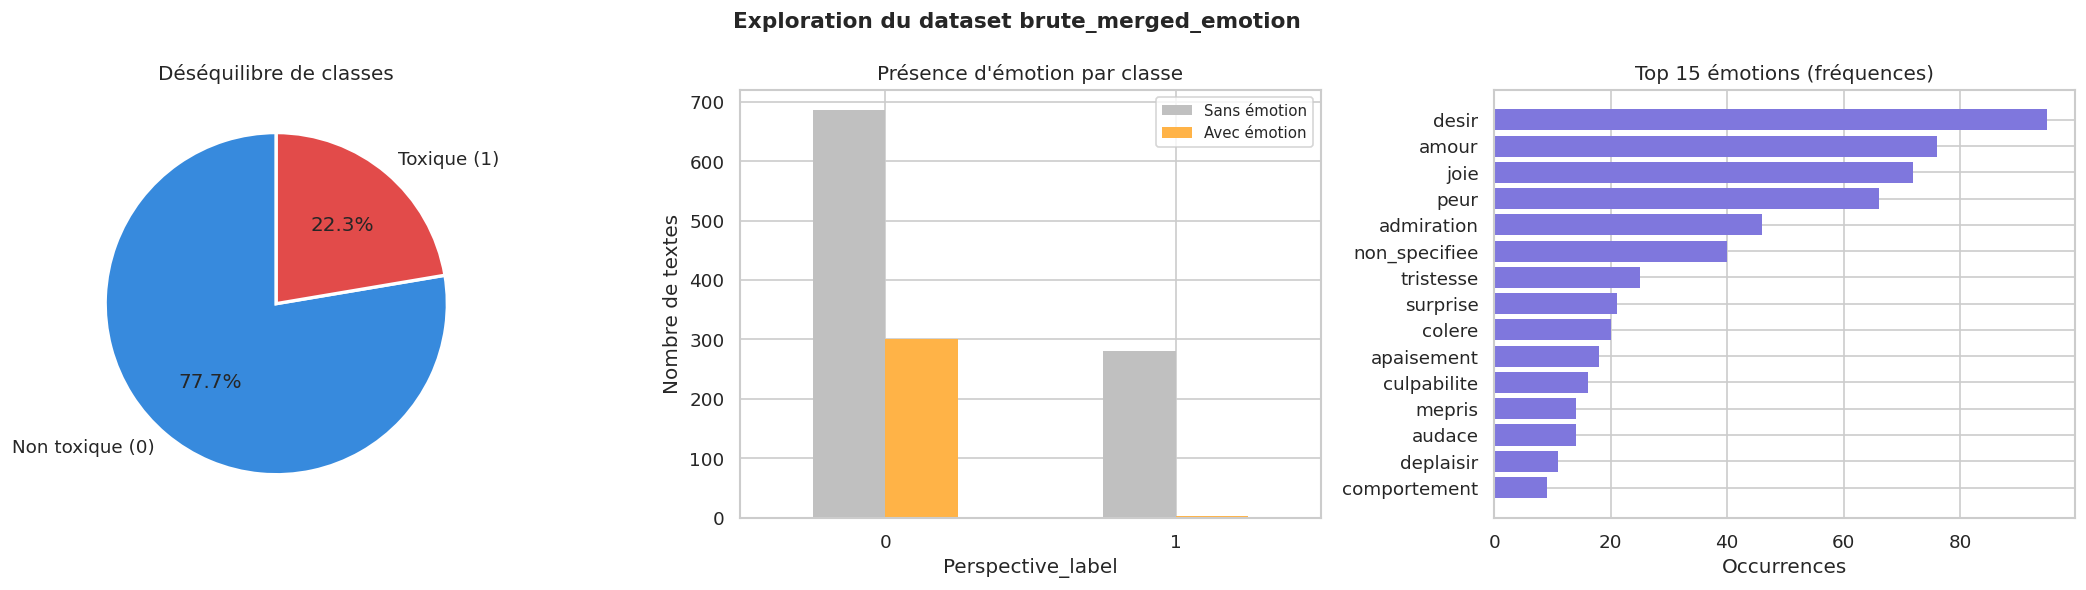


⚠️  Note : parmi les 304 textes avec émotion détectée, 301 sont non-toxiques
   → les émotions sont quasi-absentes du côté toxique : point d'analyse clé


In [ ]:


# --- Valeurs manquantes ---
print("=== Valeurs manquantes ===")
missing = df.isnull().sum()
print(missing[missing > 0])

# --- Distribution des labels ---
print("\n=== Distribution des labels ===")
print(df['Perspective_label'].value_counts().sort_index())

# --- Distribution des émotions ---
df['cats_parsed'] = df['Cats'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else [])
df['n_emotions']  = df['cats_parsed'].apply(len)
df['has_emotion'] = df['n_emotions'] > 0

print("\n=== Émotions détectées par classe ===")
print(pd.crosstab(df['Perspective_label'], df['has_emotion'],
                  rownames=['Toxique'], colnames=['A une émotion'], margins=True))

# --- Toutes les catégories d'émotions ---
all_cats = set()
for cats in df['cats_parsed']:
    all_cats.update(cats)
print(f"\nCatégories d'émotions uniques ({len(all_cats)}) : {sorted(all_cats)}")

# --- Fréquences par émotion ---
from collections import Counter
emotion_counts = Counter()
for cats in df['cats_parsed']:
    emotion_counts.update(cats)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Exploration du dataset brute_merged_emotion', fontsize=13, fontweight='bold')

# 1 Déséquilibre de classes
counts = df['Perspective_label'].value_counts()
axes[0].pie(counts, labels=['Non toxique (0)', 'Toxique (1)'],
            colors=['#378ADD', '#E24B4A'],
            autopct='%1.1f%%', startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[0].set_title('Déséquilibre de classes')

# 2 Présence d'émotions par classe
emo_tab = pd.crosstab(df['Perspective_label'], df['has_emotion'])
emo_tab.plot(kind='bar', ax=axes[1], color=['#C0C0C0', '#FFB347'], edgecolor='none')
axes[1].set_title('Présence d\'émotion par classe')
axes[1].set_xlabel('Perspective_label')
axes[1].set_ylabel('Nombre de textes')
axes[1].tick_params(axis='x', rotation=0)
axes[1].legend(['Sans émotion', 'Avec émotion'], fontsize=9)

# 3 Top émotions globales
if emotion_counts:
    top_emotions = dict(sorted(emotion_counts.items(), key=lambda x: -x[1])[:15])
    axes[2].barh(list(top_emotions.keys())[::-1], list(top_emotions.values())[::-1],
                 color='#7F77DD', edgecolor='none')
    axes[2].set_title('Top 15 émotions (fréquences)')
    axes[2].set_xlabel('Occurrences')

plt.tight_layout()
plt.savefig('exploration_dataset.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n⚠️  Note : parmi les 304 textes avec émotion détectée, 301 sont non-toxiques")
print("   → les émotions sont quasi-absentes du côté toxique : point d\'analyse clé")


In [ ]:


print(f"Shape initiale : {df.shape}")

# Étape 1 : labels valides + textes non-NaN
df_clean = df[df['Perspective_label'].isin([0, 1])].copy()
df_clean = df_clean.dropna(subset=['text'])
print(f"Après suppression NaN + labels aberrants : {df_clean.shape}")

# Étape 2 : déduplications sur le texte
df_clean = df_clean.drop_duplicates(subset='text', keep='first')
print(f"Après déduplication                       : {df_clean.shape}")

# Étape 3 : supprimer messages de bots
BOT_PATTERN = r'(I am a bot|AutoModérateur|AutoModerator|performed automatically)'
df_clean = df_clean[~df_clean['text'].astype(str).str.contains(BOT_PATTERN, case=False, regex=True)]
print(f"Après suppression bots                    : {df_clean.shape}")

# Étape 4 : textes trop courts
df_clean = df_clean[df_clean['text'].str.len() >= 3]
print(f"Après filtre < 3 chars                    : {df_clean.shape}")

# Étape 5 : nettoyage textuel
def clean_text(text: str) -> str:
    text = text.replace('_x000D_', '')
    text = re.sub(r'&gt;', '>', text)
    text = re.sub(r'&lt;', '<', text)
    text = re.sub(r'&amp;', '&', text)
    text = re.sub(r'http\S+', '[URL]', text)
    text = re.sub(r'\n{3,}', '\n\n', text)
    return text.strip()

df_clean['text_clean'] = df_clean['text'].apply(clean_text)

# Re-parser les émotions sur le dataset propre
df_clean['cats_parsed'] = df_clean['Cats'].apply(
    lambda x: ast.literal_eval(x) if pd.notna(x) else []
)

print(f"\n✅ Dataset propre : {df_clean.shape}")
print(f"   Toxique     : {(df_clean['Perspective_label']==1).sum()}")
print(f"   Non toxique : {(df_clean['Perspective_label']==0).sum()}")
display(df_clean[['text_clean', 'Perspective_label', 'Cats']].head())


Shape initiale : (1271, 12)
Après suppression NaN + labels aberrants : (1239, 12)
Après déduplication                       : (1236, 12)
Après suppression bots                    : (1232, 12)
Après filtre < 3 chars                    : (1232, 12)

✅ Dataset propre : (1232, 13)
   Toxique     : 283
   Non toxique : 949


/tmp/ipykernel_1347/3865956632.py:18: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  df_clean = df_clean[~df_clean['text'].astype(str).str.contains(BOT_PATTERN, case=False, regex=True)]


,text_clean,Perspective_label,Cats
0,"C'est dingue, après tout ce temps, plus de 15 ans après son décès, les blagues sur sa mort me font toujours autant r...",0,['joie']
1,"Plutôt d'accord pour les SAV, c'est le but même du forum que de poser des questions donc pas besoin de post.",0,[]
2,"Bordel. J'avais tapé une longue réponse. Une fausse manip sur le téléphone, et hop, perdue à jamais. J'essaierai de ...",0,[]
3,Non pas de problème de ce côté là heureusement !,0,['joie']
4,"Les violences étaient clairement motivées par l'homophobie et la misogynie, pourtant je n'ai admis que j'étais trans...",0,['desir']


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/811k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Token indices sequence length is longer than the specified maximum sequence length for this model (839 > 512). Running this sequence through the model will result in indexing errors
/tmp/ipykernel_1347/1461080386.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=valid, x='Classe', y='n_tokens',


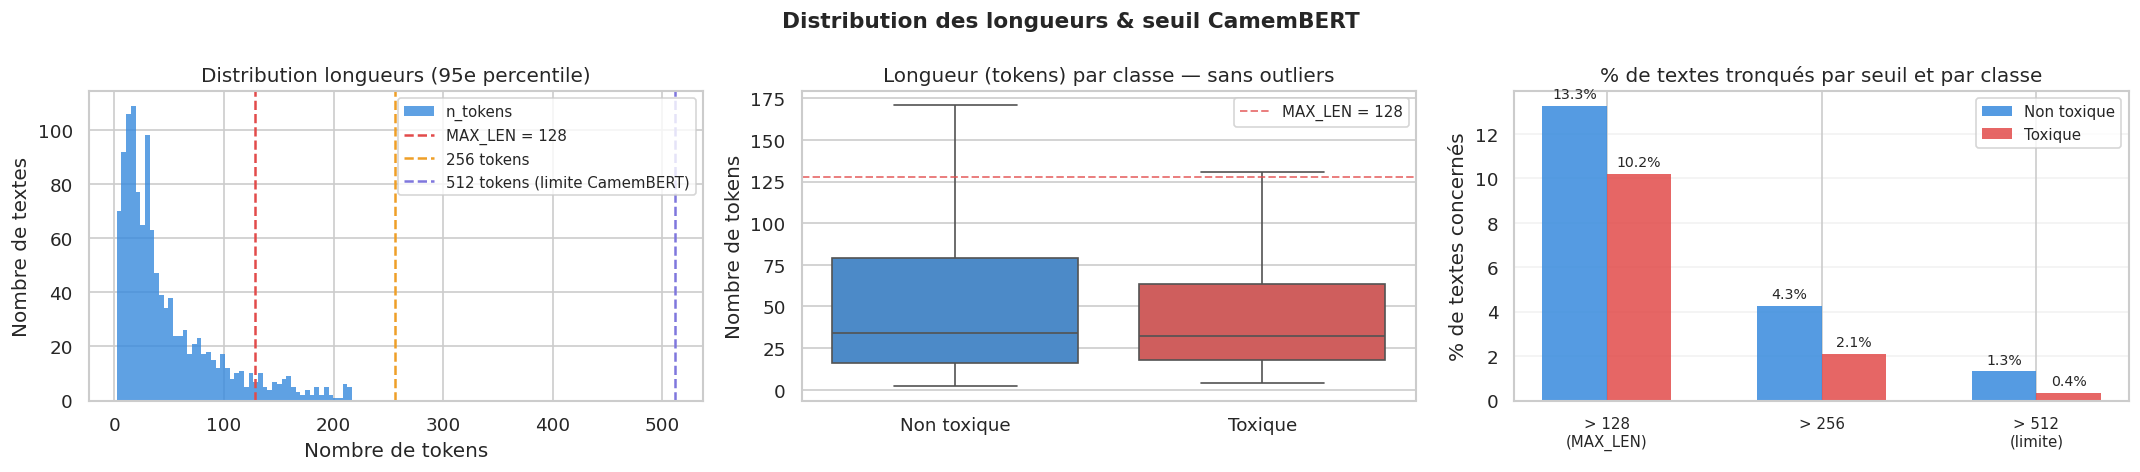

Médiane tokens          : 34
Textes > 128 tokens     : 160 (12.6%)
Textes > 256 tokens     : 48 (3.8%)
Textes > 512 tokens     : 14 (1.1%)
Textes < 10 tokens      : 128


In [ ]:


from transformers import CamembertTokenizerFast

_tokenizer = CamembertTokenizerFast.from_pretrained("camembert-base")

df['n_tokens']   = df['text'].fillna('').apply(
    lambda t: len(_tokenizer.encode(t, add_special_tokens=True))
)
df['text_len']   = df['text'].fillna('').str.len()
df['word_count'] = df['text'].fillna('').str.split().str.len()

fig, axes = plt.subplots(1, 3, figsize=(18, 4))
fig.suptitle('Distribution des longueurs & seuil CamemBERT', fontsize=13, fontweight='bold')

# ── 1 Histogramme tokens (zoom 95e percentile) ──────────────────────────────
p95 = df['n_tokens'].quantile(0.95)
df[df['n_tokens'] <= p95]['n_tokens'].plot(
    kind='hist', bins=50, ax=axes[0],
    color='#378ADD', edgecolor='none', alpha=0.8)

axes[0].axvline(128, color='#E24B4A', lw=1.5, ls='--', label='MAX_LEN = 128')
axes[0].axvline(256, color='#EF9F27', lw=1.5, ls='--', label='256 tokens')
axes[0].axvline(512, color='#7F77DD', lw=1.5, ls='--', label='512 tokens (limite CamemBERT)')
axes[0].set_title('Distribution longueurs (95e percentile)')
axes[0].set_xlabel('Nombre de tokens')
axes[0].set_ylabel('Nombre de textes')
axes[0].legend(fontsize=9)

# ── 2 Boxplot tokens par classe ──────────────────────────────────────────────
valid = df[df['Perspective_label'].isin([0, 1])].copy()
valid['Classe'] = valid['Perspective_label'].map({0: 'Non toxique', 1: 'Toxique'})
sns.boxplot(data=valid, x='Classe', y='n_tokens',
            palette={'Non toxique': '#378ADD', 'Toxique': '#E24B4A'},
            ax=axes[1], showfliers=False)
axes[1].axhline(128, color='#E24B4A', lw=1.2, ls='--', alpha=0.7, label='MAX_LEN = 128')
axes[1].set_title('Longueur (tokens) par classe — sans outliers')
axes[1].set_ylabel('Nombre de tokens')
axes[1].set_xlabel('')
axes[1].legend(fontsize=9)

# ── 3 Barres : % tronqués par classe ────────────────────────────────────────
seuils   = [128, 256, 512]
labels_s = ['> 128\n(MAX_LEN)', '> 256', '> 512\n(limite)']
x_pos    = np.arange(len(seuils))
width    = 0.3

pct_0 = [100 * (valid[valid['Classe']=='Non toxique']['n_tokens'] > s).mean() for s in seuils]
pct_1 = [100 * (valid[valid['Classe']=='Toxique'    ]['n_tokens'] > s).mean() for s in seuils]

b0 = axes[2].bar(x_pos - width/2, pct_0, width, label='Non toxique',
                  color='#378ADD', alpha=0.85, edgecolor='none')
b1 = axes[2].bar(x_pos + width/2, pct_1, width, label='Toxique',
                  color='#E24B4A', alpha=0.85, edgecolor='none')

for bar, v in [(b, val) for bars, vals in [(b0, pct_0), (b1, pct_1)]
               for b, val in zip(bars, vals)]:
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
                 f'{v:.1f}%', ha='center', va='bottom', fontsize=8.5)

axes[2].set_xticks(x_pos)
axes[2].set_xticklabels(labels_s, fontsize=9)
axes[2].set_title('% de textes tronqués par seuil et par classe')
axes[2].set_ylabel('% de textes concernés')
axes[2].legend(fontsize=9)
axes[2].grid(axis='y', alpha=0.25)

plt.tight_layout()
plt.savefig('token_length_dist.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Résumé textuel ───────────────────────────────────────────────────────────
print(f"Médiane tokens          : {df['n_tokens'].median():.0f}")
print(f"Textes > 128 tokens     : {(df['n_tokens'] > 128).sum()} ({100*(df['n_tokens'] > 128).mean():.1f}%)")
print(f"Textes > 256 tokens     : {(df['n_tokens'] > 256).sum()} ({100*(df['n_tokens'] > 256).mean():.1f}%)")
print(f"Textes > 512 tokens     : {(df['n_tokens'] > 512).sum()} ({100*(df['n_tokens'] > 512).mean():.1f}%)")
print(f"Textes < 10 tokens      : {(df['n_tokens'] < 10).sum()}")

In [ ]:


!pip install transformers torch tqdm -q

tokenizer = CamembertTokenizerFast.from_pretrained(MODEL_NAME)
model     = CamembertModel.from_pretrained(MODEL_NAME).to(DEVICE)
model.eval()

for param in model.parameters():
    param.requires_grad = False

print("✅ Modèle CamemBERT prêt (frozen)")

def mean_pooling(last_hidden_state, attention_mask):
    mask    = attention_mask.unsqueeze(-1).expand(last_hidden_state.size()).float()
    summed  = (last_hidden_state * mask).sum(dim=1)
    counts  = mask.sum(dim=1).clamp(min=1e-9)
    return summed / counts

def get_embeddings(texts, batch_size=BATCH_SIZE):
    all_embeddings = []
    for i in tqdm(range(0, len(texts), batch_size), desc="Embedding"):
        batch = texts[i:i + batch_size]
        encoded = tokenizer(batch, max_length=MAX_LEN, padding=True,
                            truncation=True, return_tensors='pt')
        input_ids      = encoded['input_ids'].to(DEVICE)
        attention_mask = encoded['attention_mask'].to(DEVICE)
        with torch.no_grad():
            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        emb = mean_pooling(outputs.last_hidden_state, attention_mask)
        all_embeddings.append(emb.cpu().numpy())
    return np.vstack(all_embeddings)

texts  = df_clean['text_clean'].tolist()
labels = df_clean['Perspective_label'].tolist()

print(f"\n📊 Dataset propre : {len(texts)} textes")
print(f"   Toxiques     : {sum(labels)}")
print(f"   Non-toxiques : {len(labels) - sum(labels)}")

X_emb = get_embeddings(texts)
y     = np.array(labels)

print(f"\n📐 Shape embeddings : {X_emb.shape}")
print("🎉 Prêt pour la classification !")

del model
torch.cuda.empty_cache()


config.json:   0%|          | 0.00/508 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/445M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

CamembertModel LOAD REPORT from: camembert-base
Key                       | Status     |  | 
--------------------------+------------+--+-
lm_head.dense.weight      | UNEXPECTED |  | 
lm_head.layer_norm.bias   | UNEXPECTED |  | 
lm_head.layer_norm.weight | UNEXPECTED |  | 
lm_head.dense.bias        | UNEXPECTED |  | 
lm_head.bias              | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


✅ Modèle CamemBERT prêt (frozen)

📊 Dataset propre : 1232 textes
   Toxiques     : 283
   Non-toxiques : 949


Embedding: 100%|██████████| 77/77 [10:54<00:00,  8.50s/it]


📐 Shape embeddings : (1232, 768)
🎉 Prêt pour la classification !


In [ ]:

mlb = MultiLabelBinarizer()
X_emotion = mlb.fit_transform(df_clean['cats_parsed'])

print(f"Catégories d\'émotions encodées ({len(mlb.classes_)}) : {mlb.classes_.tolist()}")
print(f"Shape features émotionnelles : {X_emotion.shape}")
print(f"Densité (lignes avec ≥1 émotion) : {(X_emotion.sum(axis=1) > 0).sum()} / {len(X_emotion)}")

# Vérification croisée avec labels
import pandas as pd
emo_df = pd.DataFrame(X_emotion, columns=mlb.classes_)
emo_df['label'] = y
print("\n=== Somme des émotions par classe ===")
print(emo_df.groupby('label').sum().T.to_string())


Catégories d'émotions encodées (23) : ['admiration', 'amour', 'apaisement', 'audace', 'colere', 'comportement', 'culpabilite', 'degout', 'deplaisir', 'desir', 'embarras', 'empathie', 'fierte', 'impassibilite', 'inhumanite', 'joie', 'mepris', 'non_specifiee', 'orgueil', 'peur', 'ressentiment', 'surprise', 'tristesse']
Shape features émotionnelles : (1232, 23)
Densité (lignes avec ≥1 émotion) : 299 / 1232

=== Somme des émotions par classe ===
label           0  1
admiration     34  0
amour          63  1
apaisement     17  0
audace         14  0
colere         16  2
comportement    8  0
culpabilite    13  0
degout          4  0
deplaisir      11  0
desir          72  0
embarras        7  0
empathie        2  0
fierte          6  0
impassibilite   3  0
inhumanite      5  0
joie           62  1
mepris         11  1
non_specifiee  32  0
orgueil         7  0
peur           54  0
ressentiment    8  0
surprise       16  0
tristesse      22  0


In [ ]:


from sklearn.model_selection import train_test_split

# Version A : embeddings seuls
X_A = X_emb

# Version B : embeddings + émotions
X_B = np.hstack([X_emb, X_emotion])

# Split commun (même seed → comparaison valide)
X_A_train, X_A_test, y_train, y_test = train_test_split(
    X_A, y, test_size=0.2, random_state=42, stratify=y
)
X_B_train, X_B_test, _, _ = train_test_split(
    X_B, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train : {X_A_train.shape[0]} exemples | Test : {X_A_test.shape[0]} exemples")
print(f"  Train toxique : {y_train.sum()} | Test toxique : {y_test.sum()}")
print(f"Shape X_A_train : {X_A_train.shape}")
print(f"Shape X_B_train : {X_B_train.shape}")

Train : 985 exemples | Test : 247 exemples
  Train toxique : 226 | Test toxique : 57
Shape X_A_train : (985, 768)
Shape X_B_train : (985, 791)


In [ ]:

!pip install imbalanced-learn -q

from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_A_train_sm, y_train_sm_A = smote.fit_resample(X_A_train, y_train)
X_B_train_sm, y_train_sm_B = smote.fit_resample(X_B_train, y_train)

print("=== Après SMOTE ===")
print(f"Version A — train SMOTE : {X_A_train_sm.shape} | répartition : {dict(zip(*np.unique(y_train_sm_A, return_counts=True)))}")
print(f"Version B — train SMOTE : {X_B_train_sm.shape} | répartition : {dict(zip(*np.unique(y_train_sm_B, return_counts=True)))}")


=== Après SMOTE ===
Version A — train SMOTE : (1518, 768) | répartition : {np.int64(0): np.int64(759), np.int64(1): np.int64(759)}
Version B — train SMOTE : (1518, 791) | répartition : {np.int64(0): np.int64(759), np.int64(1): np.int64(759)}


In [ ]:


def evaluate_model(name, clf, X_test, y_test, version_label=""):
    y_pred = clf.predict(X_test)
    acc  = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec  = recall_score(y_test, y_pred, zero_division=0)
    f1   = f1_score(y_test, y_pred, zero_division=0)

    title = f"[{version_label}] {name}"
    print(f"\n{'='*60}")
    print(f"  {title}")
    print(f"{'='*60}")
    print(f"  Accuracy  = {acc:.4f}")
    print(f"  Precision = {prec:.4f}")
    print(f"  Recall    = {rec:.4f}")
    print(f"  F1-score  = {f1:.4f}")
    print(classification_report(y_test, y_pred,
                                 target_names=['Non-toxique (0)', 'Toxique (1)']))
    return y_pred, {"name": title, "acc": acc, "prec": prec, "rec": rec, "f1": f1}


def plot_confusion(y_test, y_pred, title, ax):
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                   display_labels=['Non-toxique', 'Toxique'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(title, fontsize=10, fontweight='bold')


def plot_learning_curve(clf, X_train, y_train, title, ax, color='#E24B4A'):
    train_sizes_abs, train_scores, val_scores = learning_curve(
        clf, X_train, y_train,
        train_sizes=np.linspace(0.1, 1.0, 8),
        cv=5, scoring='f1', n_jobs=-1, shuffle=True, random_state=42
    )
    t_mean, t_std = train_scores.mean(1), train_scores.std(1)
    v_mean, v_std = val_scores.mean(1),   val_scores.std(1)

    ax.plot(train_sizes_abs, t_mean, 'o-', color='#1565C0', lw=2, label='Train')
    ax.fill_between(train_sizes_abs, t_mean-t_std, t_mean+t_std, alpha=0.12, color='#1565C0')
    ax.plot(train_sizes_abs, v_mean, 'o-', color=color, lw=2, label='Validation')
    ax.fill_between(train_sizes_abs, v_mean-v_std, v_mean+v_std, alpha=0.12, color=color)
    ax.axhline(0.7, color='gray', ls='--', lw=1, alpha=0.6)

    gap = t_mean[-1] - v_mean[-1]
    if gap > 0.25:   diag, dc = "⚠ OVERFIT", "#e53935"
    elif gap > 0.10: diag, dc = "△ Légère variance", "#FB8C00"
    else:            diag, dc = "✓ Bonne généralisation", "#43A047"

    ax.set_title(f"{title}\n{diag}", fontsize=9, fontweight='bold', color=dc)
    ax.set_xlabel("Exemples d\'entraînement", fontsize=8)
    ax.set_ylabel("F1 (classe toxique)", fontsize=8)
    ax.set_ylim(0, 1.05)
    ax.legend(fontsize=8)
    ax.grid(alpha=0.2)
    return gap, diag


print("✅ Fonctions d\'évaluation définies")

✅ Fonctions d'évaluation définies


---
## ═══════════════════════════════════════
## VERSION A — CamemBERT embeddings seuls (sans émotions)
## ═══════════════════════════════════════

In [ ]:


clf_A_v1 = make_pipeline(
    StandardScaler(),
    LogisticRegression(max_iter=2000, solver='lbfgs', random_state=42)
)
clf_A_v1.fit(X_A_train_sm, y_train_sm_A)

y_pred_A_v1, metrics_A_v1 = evaluate_model(
    "LR + SMOTE", clf_A_v1, X_A_test, y_test, version_label="A"
)


  [A] LR + SMOTE
  Accuracy  = 0.7652
  Precision = 0.4930
  Recall    = 0.6140
  F1-score  = 0.5469
                 precision    recall  f1-score   support

Non-toxique (0)       0.88      0.81      0.84       190
    Toxique (1)       0.49      0.61      0.55        57

       accuracy                           0.77       247
      macro avg       0.68      0.71      0.69       247
   weighted avg       0.79      0.77      0.77       247



In [ ]:


clf_A_v2 = make_pipeline(
    StandardScaler(),
    LogisticRegression(max_iter=2000, class_weight='balanced',
                       solver='lbfgs', random_state=42)
)
clf_A_v2.fit(X_A_train, y_train)

y_pred_A_v2, metrics_A_v2 = evaluate_model(
    "LR + class_weight", clf_A_v2, X_A_test, y_test, version_label="A"
)


  [A] LR + class_weight
  Accuracy  = 0.7733
  Precision = 0.5072
  Recall    = 0.6140
  F1-score  = 0.5556
                 precision    recall  f1-score   support

Non-toxique (0)       0.88      0.82      0.85       190
    Toxique (1)       0.51      0.61      0.56        57

       accuracy                           0.77       247
      macro avg       0.69      0.72      0.70       247
   weighted avg       0.79      0.77      0.78       247



In [ ]:


clf_A_v3 = make_pipeline(
    StandardScaler(),
    SVC(kernel='rbf', class_weight='balanced', probability=True,
        C=1.0, gamma='scale', random_state=42)
)
clf_A_v3.fit(X_A_train, y_train)

y_pred_A_v3, metrics_A_v3 = evaluate_model(
    "SVM + class_weight", clf_A_v3, X_A_test, y_test, version_label="A"
)


  [A] SVM + class_weight
  Accuracy  = 0.8704
  Precision = 0.7358
  Recall    = 0.6842
  F1-score  = 0.7091
                 precision    recall  f1-score   support

Non-toxique (0)       0.91      0.93      0.92       190
    Toxique (1)       0.74      0.68      0.71        57

       accuracy                           0.87       247
      macro avg       0.82      0.81      0.81       247
   weighted avg       0.87      0.87      0.87       247



In [ ]:


clf_A_v4 = make_pipeline(
    StandardScaler(),
    SVC(kernel='rbf', probability=True, C=1.0, gamma='scale', random_state=42)
)
clf_A_v4.fit(X_A_train_sm, y_train_sm_A)

y_pred_A_v4, metrics_A_v4 = evaluate_model(
    "SVM + SMOTE", clf_A_v4, X_A_test, y_test, version_label="A"
)


  [A] SVM + SMOTE
  Accuracy  = 0.8583
  Precision = 0.7391
  Recall    = 0.5965
  F1-score  = 0.6602
                 precision    recall  f1-score   support

Non-toxique (0)       0.89      0.94      0.91       190
    Toxique (1)       0.74      0.60      0.66        57

       accuracy                           0.86       247
      macro avg       0.81      0.77      0.79       247
   weighted avg       0.85      0.86      0.85       247



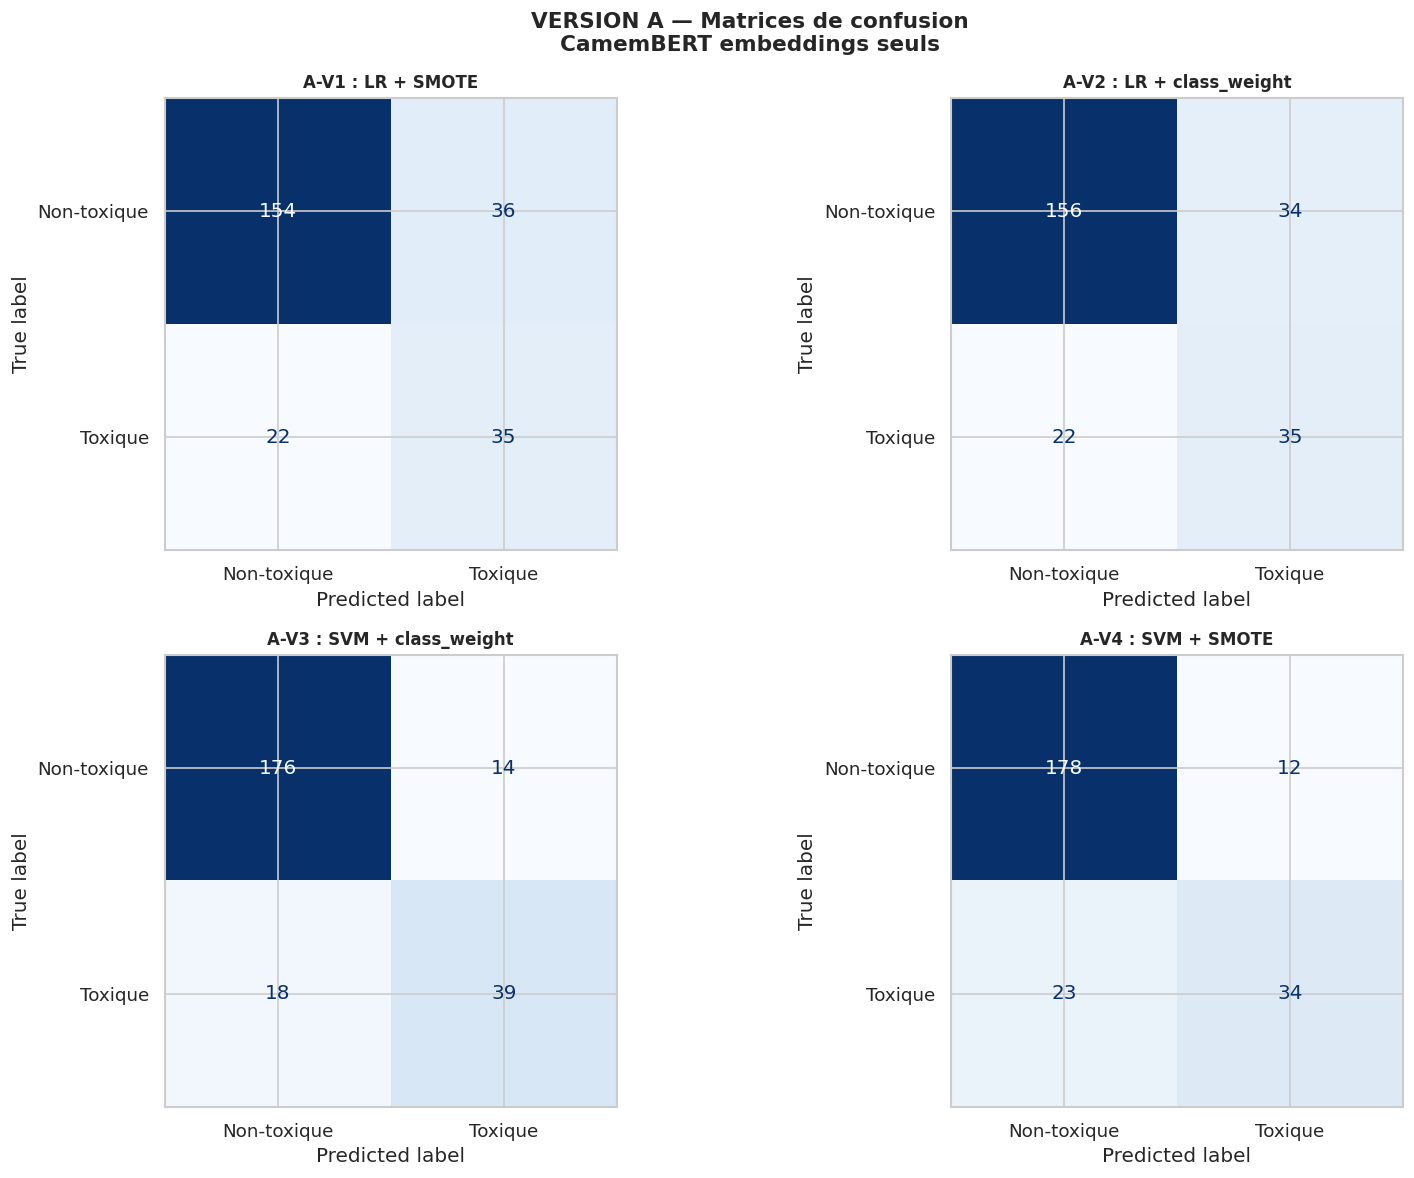

In [ ]:


fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('VERSION A — Matrices de confusion\nCamemBERT embeddings seuls',
             fontsize=13, fontweight='bold')
axes = axes.flatten()

configs = [
    (y_pred_A_v1, "A-V1 : LR + SMOTE"),
    (y_pred_A_v2, "A-V2 : LR + class_weight"),
    (y_pred_A_v3, "A-V3 : SVM + class_weight"),
    (y_pred_A_v4, "A-V4 : SVM + SMOTE"),
]
for ax, (y_pred, title) in zip(axes, configs):
    plot_confusion(y_test, y_pred, title, ax)

plt.tight_layout()
plt.savefig('A_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()


⏳ A-V1 : LR + SMOTE...
⏳ A-V2 : LR + class_weight...
⏳ A-V3 : SVM + class_weight...
⏳ A-V4 : SVM + SMOTE...


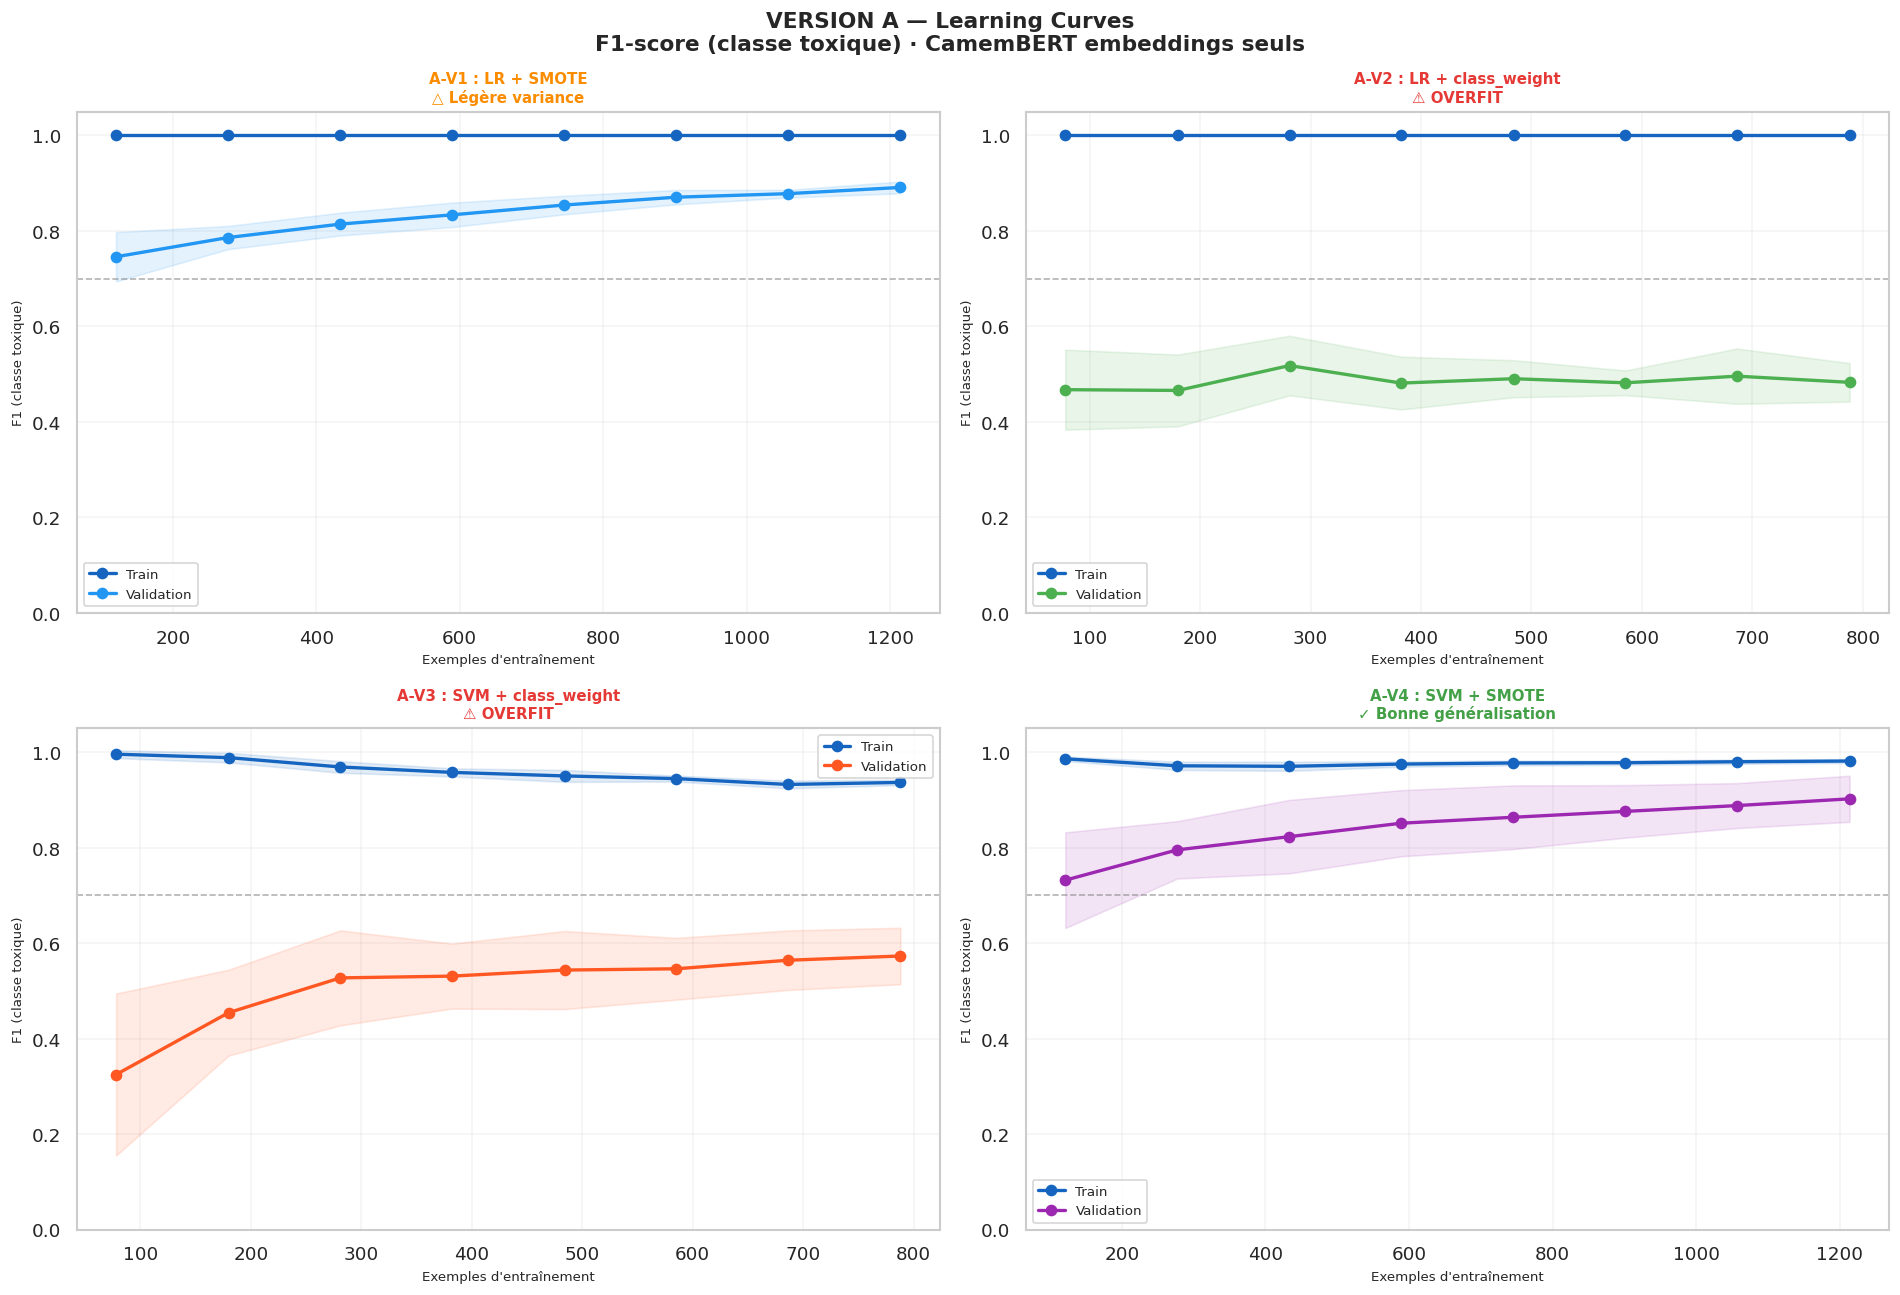


✅ Learning curves Version A sauvegardées


In [ ]:


fig, axes = plt.subplots(2, 2, figsize=(16, 11))
fig.suptitle('VERSION A — Learning Curves\nF1-score (classe toxique) · CamemBERT embeddings seuls',
             fontsize=13, fontweight='bold')
axes = axes.flatten()

lc_configs = [
    (clf_A_v1, X_A_train_sm, y_train_sm_A, "A-V1 : LR + SMOTE",         "#2196F3"),
    (clf_A_v2, X_A_train,    y_train,       "A-V2 : LR + class_weight",   "#4CAF50"),
    (clf_A_v3, X_A_train,    y_train,       "A-V3 : SVM + class_weight",  "#FF5722"),
    (clf_A_v4, X_A_train_sm, y_train_sm_A, "A-V4 : SVM + SMOTE",         "#9C27B0"),
]

for ax, (clf, X_tr, y_tr, title, color) in zip(axes, lc_configs):
    print(f"⏳ {title}...")
    plot_learning_curve(clf, X_tr, y_tr, title, ax, color)

plt.tight_layout()
plt.savefig('A_learning_curves.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print("\n✅ Learning curves Version A sauvegardées")



=== VERSION A — Récapitulatif métriques ===


,acc,prec,rec,f1
name,,,,
[A] LR + SMOTE,0.7652,0.4930,0.6140,0.5469
[A] LR + class_weight,0.7733,0.5072,0.6140,0.5556
[A] SVM + class_weight,0.8704,0.7358,0.6842,0.7091
[A] SVM + SMOTE,0.8583,0.7391,0.5965,0.6602


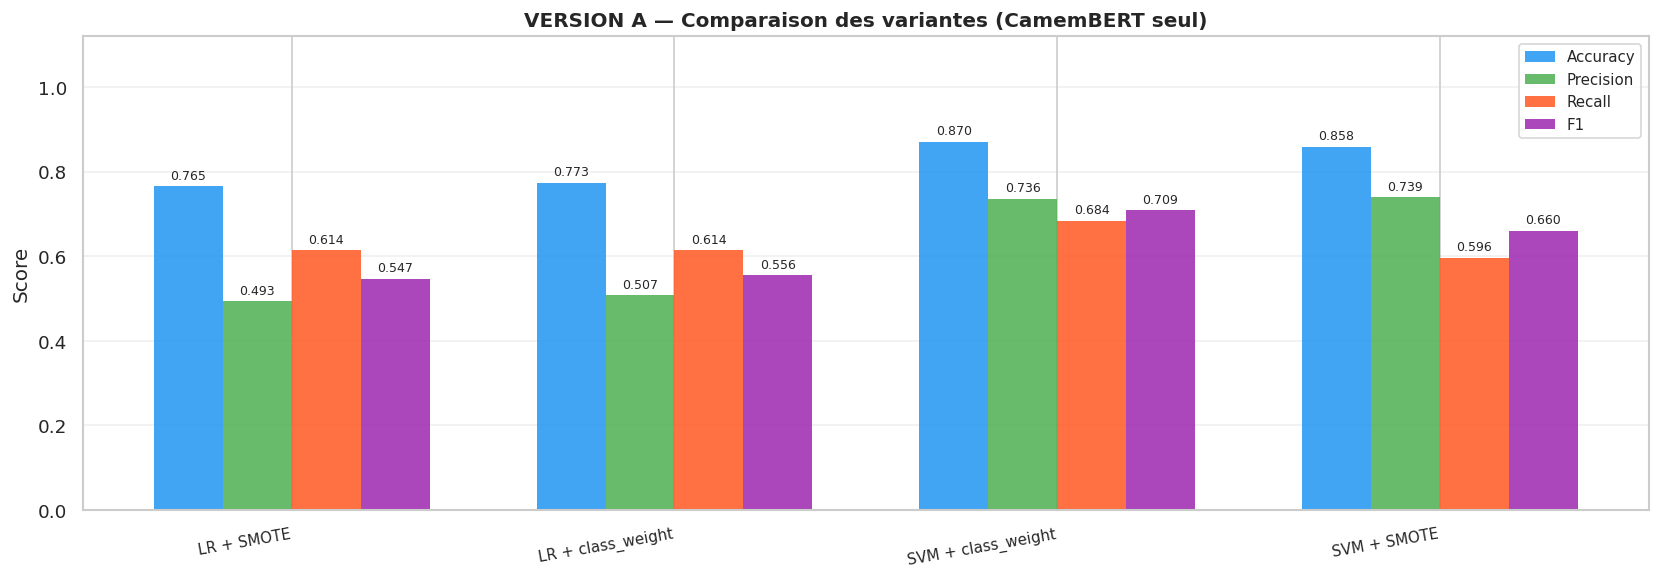

In [ ]:


all_metrics_A = [metrics_A_v1, metrics_A_v2, metrics_A_v3, metrics_A_v4]
df_results_A  = pd.DataFrame(all_metrics_A).set_index('name')
print("\n=== VERSION A — Récapitulatif métriques ===")
display(df_results_A.round(4))

metrics_to_plot = ['acc', 'prec', 'rec', 'f1']
labels_m        = ['Accuracy', 'Precision', 'Recall', 'F1']
colors_m        = ['#2196F3', '#4CAF50', '#FF5722', '#9C27B0']

x       = np.arange(len(df_results_A))
n_met   = len(metrics_to_plot)
width   = 0.18

fig, ax = plt.subplots(figsize=(14, 5))
for i, (met, col, lab) in enumerate(zip(metrics_to_plot, colors_m, labels_m)):
    vals = df_results_A[met].values
    bars = ax.bar(x + (i - n_met/2 + 0.5) * width, vals, width,
                  label=lab, color=col, alpha=0.85, edgecolor='none')
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{v:.3f}', ha='center', va='bottom', fontsize=7.5)

ax.set_xticks(x)
ax.set_xticklabels([m.split(']')[1].strip() for m in df_results_A.index],
                    rotation=10, ha='right', fontsize=9)
ax.set_ylim(0, 1.12)
ax.set_ylabel('Score')
ax.set_title('VERSION A — Comparaison des variantes (CamemBERT seul)', fontweight='bold')
ax.legend(fontsize=9)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('A_comparaison.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()


---
## ═══════════════════════════════════════
## VERSION B — CamemBERT embeddings + features émotionnelles
## ═══════════════════════════════════════

In [ ]:


clf_B_v1 = make_pipeline(
    StandardScaler(),
    LogisticRegression(max_iter=2000, solver='lbfgs', random_state=42)
)
clf_B_v1.fit(X_B_train_sm, y_train_sm_B)

y_pred_B_v1, metrics_B_v1 = evaluate_model(
    "LR + SMOTE", clf_B_v1, X_B_test, y_test, version_label="B"
)


  [B] LR + SMOTE
  Accuracy  = 0.7976
  Precision = 0.5507
  Recall    = 0.6667
  F1-score  = 0.6032
                 precision    recall  f1-score   support

Non-toxique (0)       0.89      0.84      0.86       190
    Toxique (1)       0.55      0.67      0.60        57

       accuracy                           0.80       247
      macro avg       0.72      0.75      0.73       247
   weighted avg       0.81      0.80      0.80       247



In [ ]:


clf_B_v2 = make_pipeline(
    StandardScaler(),
    LogisticRegression(max_iter=2000, class_weight='balanced',
                       solver='lbfgs', random_state=42)
)
clf_B_v2.fit(X_B_train, y_train)

y_pred_B_v2, metrics_B_v2 = evaluate_model(
    "LR + class_weight", clf_B_v2, X_B_test, y_test, version_label="B"
)



  [B] LR + class_weight
  Accuracy  = 0.7814
  Precision = 0.5211
  Recall    = 0.6491
  F1-score  = 0.5781
                 precision    recall  f1-score   support

Non-toxique (0)       0.89      0.82      0.85       190
    Toxique (1)       0.52      0.65      0.58        57

       accuracy                           0.78       247
      macro avg       0.70      0.74      0.72       247
   weighted avg       0.80      0.78      0.79       247



In [ ]:


clf_B_v3 = make_pipeline(
    StandardScaler(),
    SVC(kernel='rbf', class_weight='balanced', probability=True,
        C=1.0, gamma='scale', random_state=42)
)
clf_B_v3.fit(X_B_train, y_train)

y_pred_B_v3, metrics_B_v3 = evaluate_model(
    "SVM + class_weight", clf_B_v3, X_B_test, y_test, version_label="B"
)



  [B] SVM + class_weight
  Accuracy  = 0.8745
  Precision = 0.7500
  Recall    = 0.6842
  F1-score  = 0.7156
                 precision    recall  f1-score   support

Non-toxique (0)       0.91      0.93      0.92       190
    Toxique (1)       0.75      0.68      0.72        57

       accuracy                           0.87       247
      macro avg       0.83      0.81      0.82       247
   weighted avg       0.87      0.87      0.87       247



In [ ]:


clf_B_v4 = make_pipeline(
    StandardScaler(),
    SVC(kernel='rbf', probability=True, C=1.0, gamma='scale', random_state=42)
)
clf_B_v4.fit(X_B_train_sm, y_train_sm_B)

y_pred_B_v4, metrics_B_v4 = evaluate_model(
    "SVM + SMOTE", clf_B_v4, X_B_test, y_test, version_label="B"
)



  [B] SVM + SMOTE
  Accuracy  = 0.8826
  Precision = 0.8182
  Recall    = 0.6316
  F1-score  = 0.7129
                 precision    recall  f1-score   support

Non-toxique (0)       0.90      0.96      0.93       190
    Toxique (1)       0.82      0.63      0.71        57

       accuracy                           0.88       247
      macro avg       0.86      0.79      0.82       247
   weighted avg       0.88      0.88      0.88       247



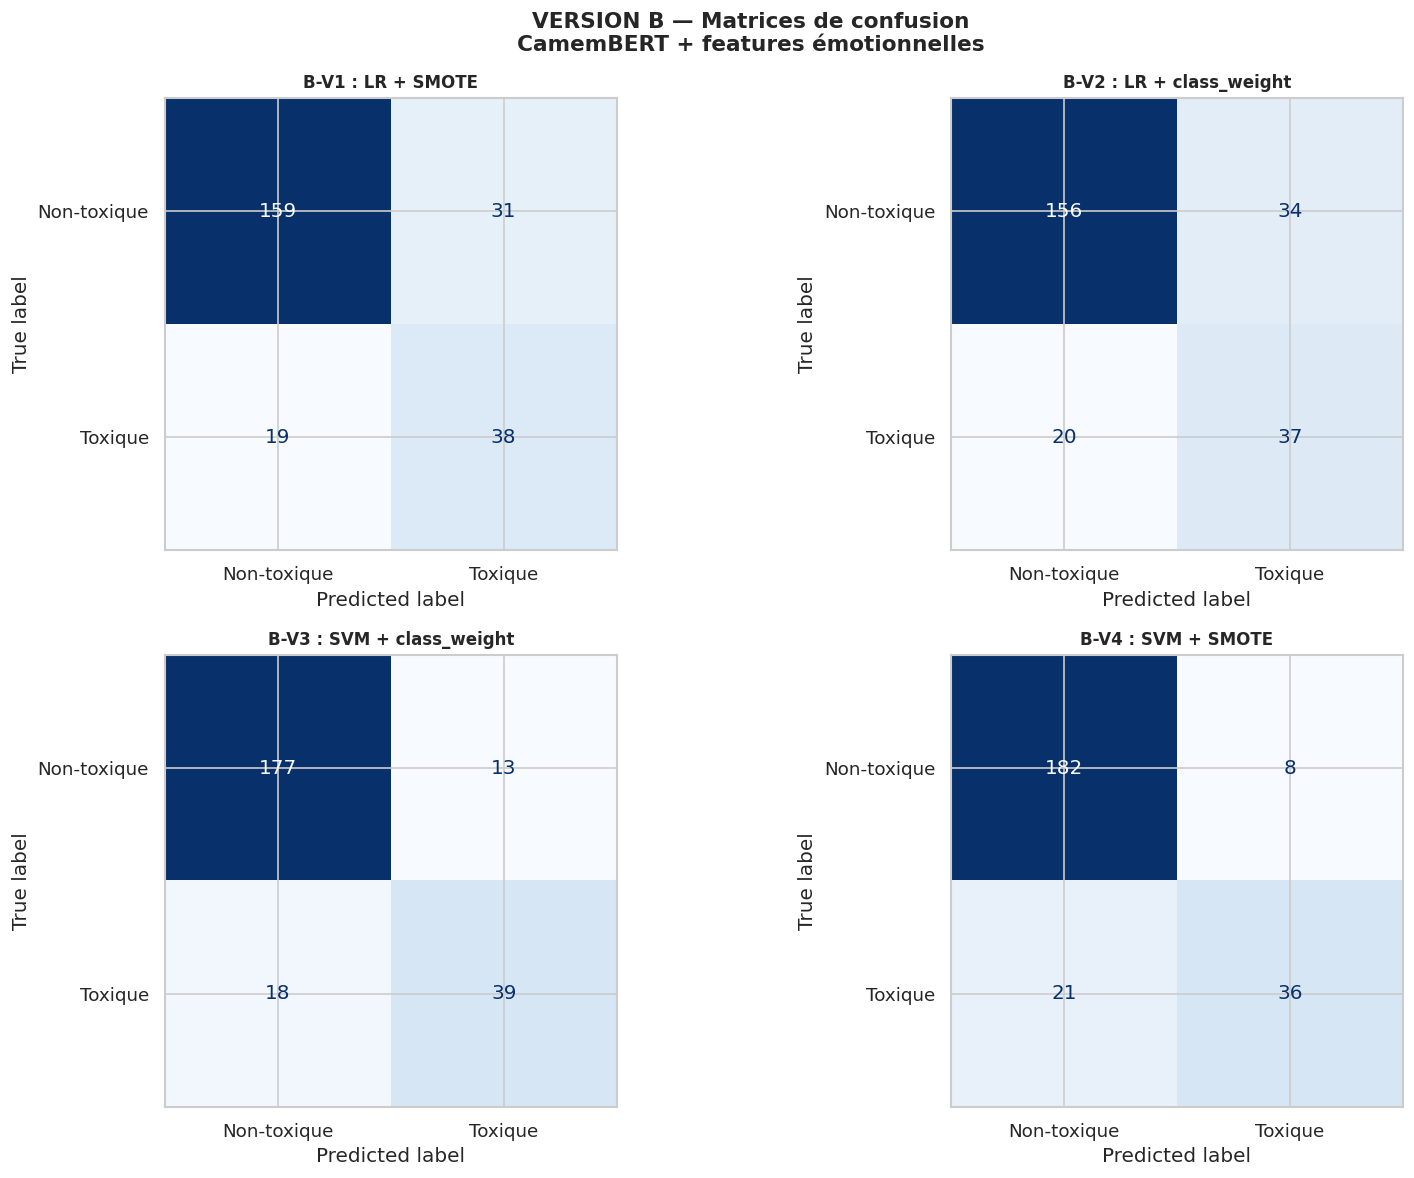

In [ ]:


fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('VERSION B — Matrices de confusion\nCamemBERT + features émotionnelles',
             fontsize=13, fontweight='bold')
axes = axes.flatten()

configs_B = [
    (y_pred_B_v1, "B-V1 : LR + SMOTE"),
    (y_pred_B_v2, "B-V2 : LR + class_weight"),
    (y_pred_B_v3, "B-V3 : SVM + class_weight"),
    (y_pred_B_v4, "B-V4 : SVM + SMOTE"),
]
for ax, (y_pred, title) in zip(axes, configs_B):
    plot_confusion(y_test, y_pred, title, ax)

plt.tight_layout()
plt.savefig('B_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()


⏳ B-V1 : LR + SMOTE...
⏳ B-V2 : LR + class_weight...
⏳ B-V3 : SVM + class_weight...
⏳ B-V4 : SVM + SMOTE...


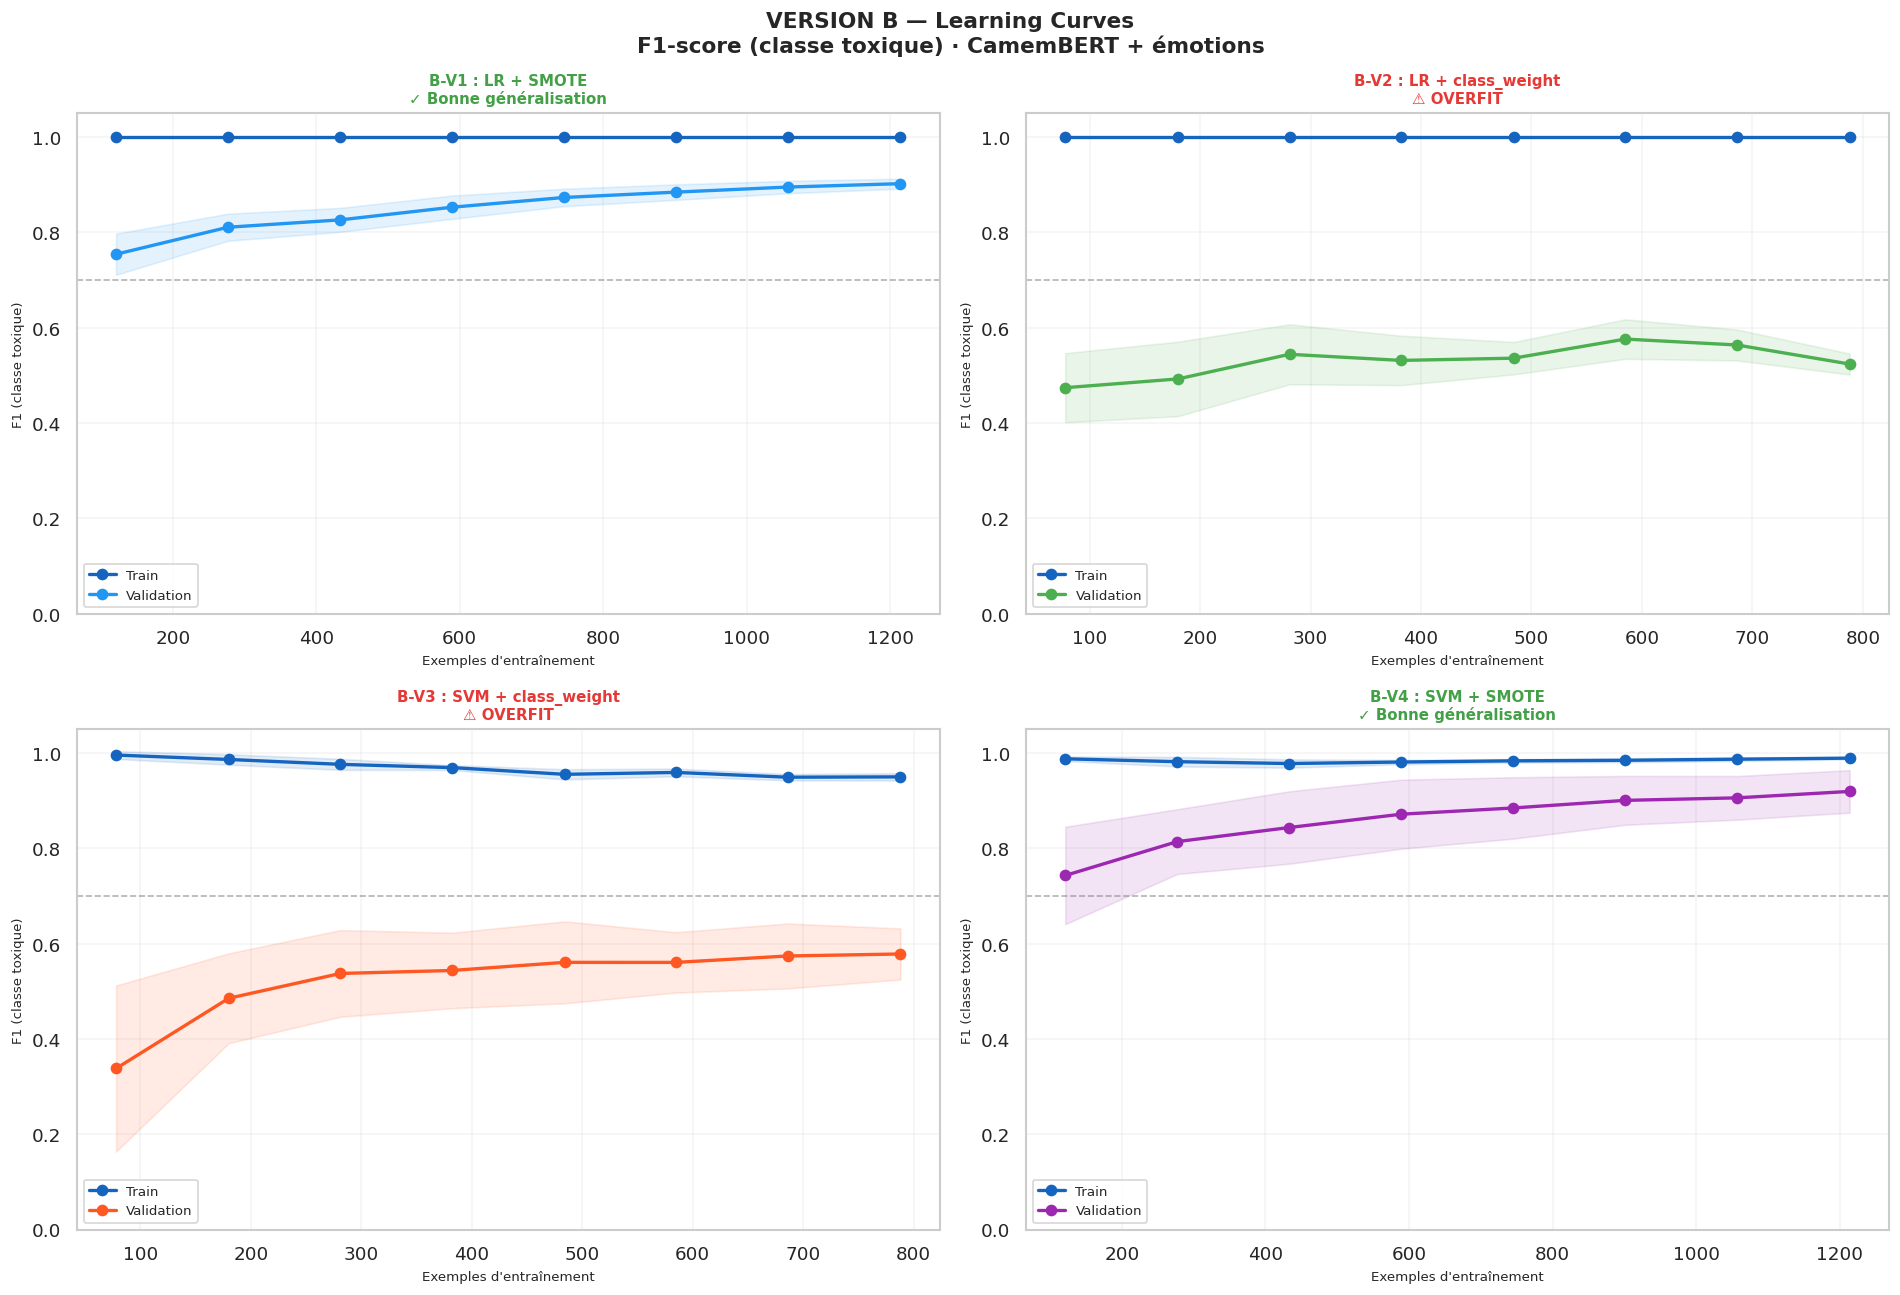


✅ Learning curves Version B sauvegardées


In [ ]:


fig, axes = plt.subplots(2, 2, figsize=(16, 11))
fig.suptitle('VERSION B — Learning Curves\nF1-score (classe toxique) · CamemBERT + émotions',
             fontsize=13, fontweight='bold')
axes = axes.flatten()

lc_configs_B = [
    (clf_B_v1, X_B_train_sm, y_train_sm_B, "B-V1 : LR + SMOTE",         "#2196F3"),
    (clf_B_v2, X_B_train,    y_train,       "B-V2 : LR + class_weight",   "#4CAF50"),
    (clf_B_v3, X_B_train,    y_train,       "B-V3 : SVM + class_weight",  "#FF5722"),
    (clf_B_v4, X_B_train_sm, y_train_sm_B, "B-V4 : SVM + SMOTE",         "#9C27B0"),
]

for ax, (clf, X_tr, y_tr, title, color) in zip(axes, lc_configs_B):
    print(f"⏳ {title}...")
    plot_learning_curve(clf, X_tr, y_tr, title, ax, color)

plt.tight_layout()
plt.savefig('B_learning_curves.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print("\n✅ Learning curves Version B sauvegardées")



=== VERSION B — Récapitulatif métriques ===


,acc,prec,rec,f1
name,,,,
[B] LR + SMOTE,0.7976,0.5507,0.6667,0.6032
[B] LR + class_weight,0.7814,0.5211,0.6491,0.5781
[B] SVM + class_weight,0.8745,0.7500,0.6842,0.7156
[B] SVM + SMOTE,0.8826,0.8182,0.6316,0.7129


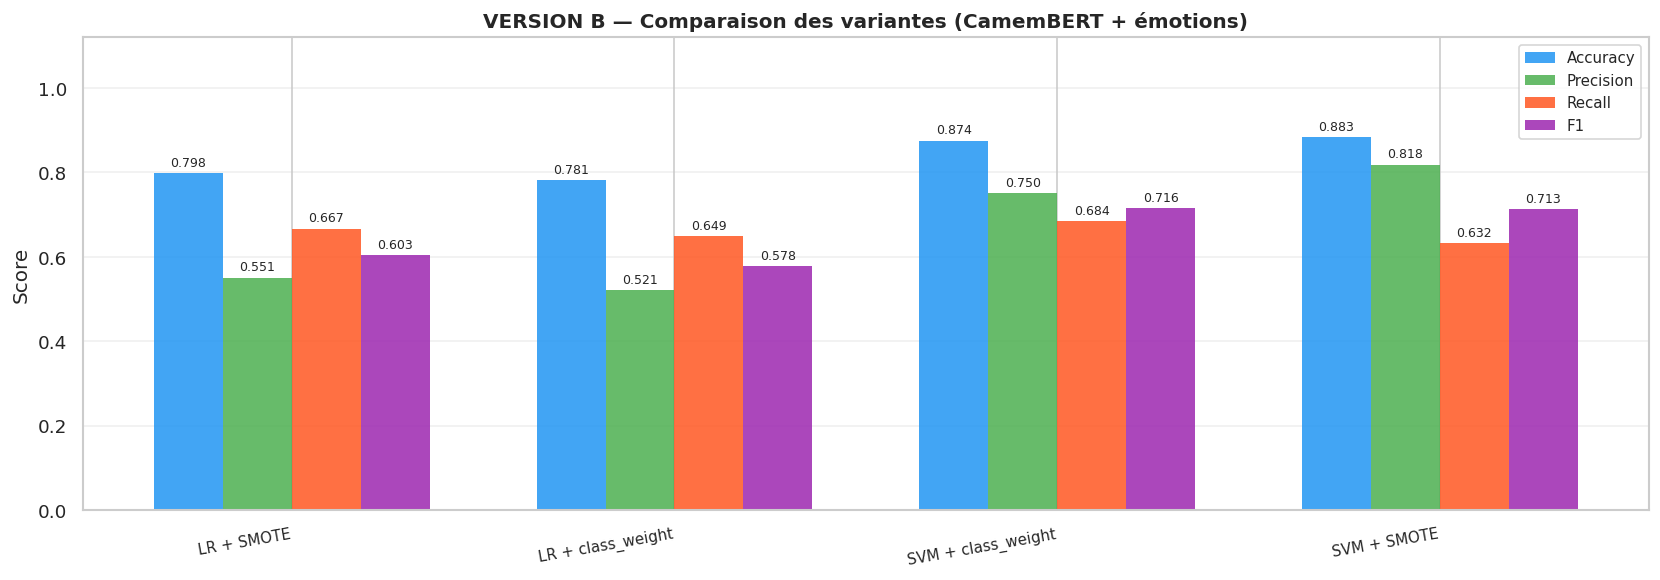

In [ ]:


all_metrics_B = [metrics_B_v1, metrics_B_v2, metrics_B_v3, metrics_B_v4]
df_results_B  = pd.DataFrame(all_metrics_B).set_index('name')
print("\n=== VERSION B — Récapitulatif métriques ===")
display(df_results_B.round(4))

fig, ax = plt.subplots(figsize=(14, 5))
for i, (met, col, lab) in enumerate(zip(metrics_to_plot, colors_m, labels_m)):
    vals = df_results_B[met].values
    bars = ax.bar(x + (i - n_met/2 + 0.5) * width, vals, width,
                  label=lab, color=col, alpha=0.85, edgecolor='none')
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{v:.3f}', ha='center', va='bottom', fontsize=7.5)

ax.set_xticks(x)
ax.set_xticklabels([m.split(']')[1].strip() for m in df_results_B.index],
                    rotation=10, ha='right', fontsize=9)
ax.set_ylim(0, 1.12)
ax.set_ylabel('Score')
ax.set_title('VERSION B — Comparaison des variantes (CamemBERT + émotions)', fontweight='bold')
ax.legend(fontsize=9)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('B_comparaison.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()


---
## ═══════════════════════════════════════
## Comparaison finale A vs B — L'ajout des émotions apporte-t-il un gain ?
## ═══════════════════════════════════════


=== Comparaison finale A vs B ===


,F1 Version A (sans émotions),F1 Version B (avec émotions),Delta (B - A),Gain ?
Variante,,,,
LR + SMOTE,0.5469,0.6032,0.0563,+
LR + class_weight,0.5556,0.5781,0.0226,+
SVM + class_weight,0.7091,0.7156,0.0065,+
SVM + SMOTE,0.6602,0.7129,0.0527,+


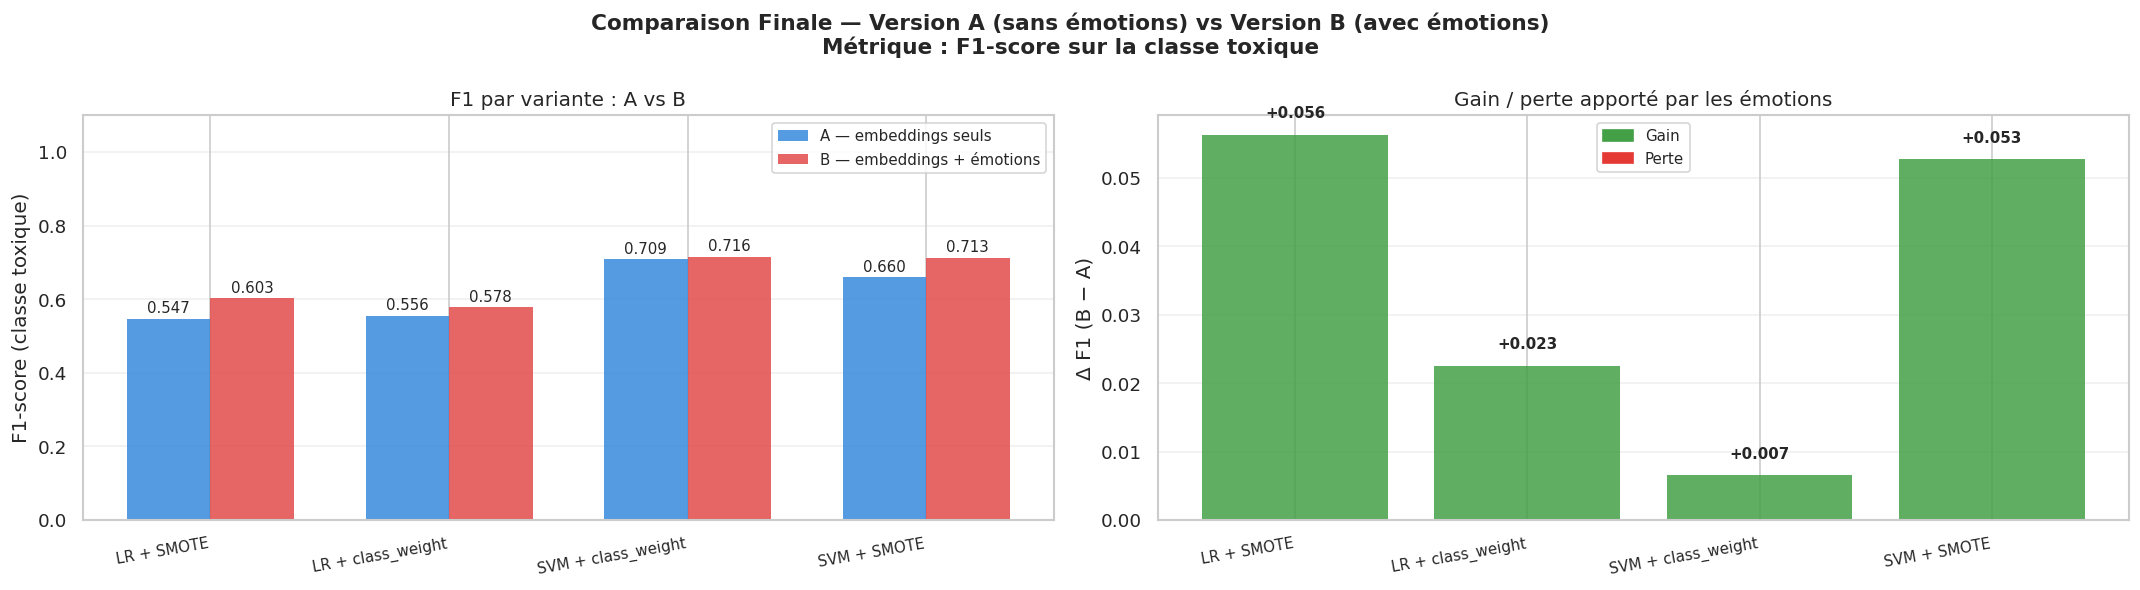

✅ Graphe de comparaison finale sauvegardé


In [ ]:


variantes = ['LR + SMOTE', 'LR + class_weight', 'SVM + class_weight', 'SVM + SMOTE']

f1_A = [metrics_A_v1['f1'], metrics_A_v2['f1'], metrics_A_v3['f1'], metrics_A_v4['f1']]
f1_B = [metrics_B_v1['f1'], metrics_B_v2['f1'], metrics_B_v3['f1'], metrics_B_v4['f1']]

delta = [b - a for a, b in zip(f1_A, f1_B)]

# Tableau récapitulatif
df_compare = pd.DataFrame({
    'Variante': variantes,
    'F1 Version A (sans émotions)': f1_A,
    'F1 Version B (avec émotions)': f1_B,
    'Delta (B - A)': delta,
    'Gain ?': ['+' if d > 0 else ('=' if d == 0 else '-') for d in delta]
}).set_index('Variante')

print("\n=== Comparaison finale A vs B ===")
display(df_compare.round(4))

# Graphe
x_pos = np.arange(len(variantes))
width = 0.35

fig, axes = plt.subplots(1, 2, figsize=(18, 5))
fig.suptitle('Comparaison Finale — Version A (sans émotions) vs Version B (avec émotions)\n'
             'Métrique : F1-score sur la classe toxique',
             fontsize=13, fontweight='bold')

# Barres côte à côte
bars_A = axes[0].bar(x_pos - width/2, f1_A, width, label='A — embeddings seuls',
                     color='#378ADD', alpha=0.85, edgecolor='none')
bars_B = axes[0].bar(x_pos + width/2, f1_B, width, label='B — embeddings + émotions',
                     color='#E24B4A', alpha=0.85, edgecolor='none')

for bar, v in [(b, f) for b, f in zip(list(bars_A) + list(bars_B), f1_A + f1_B)]:
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.008,
                 f'{v:.3f}', ha='center', va='bottom', fontsize=9)

axes[0].set_xticks(x_pos)
axes[0].set_xticklabels(variantes, rotation=10, ha='right', fontsize=9)
axes[0].set_ylim(0, 1.1)
axes[0].set_ylabel('F1-score (classe toxique)')
axes[0].set_title('F1 par variante : A vs B')
axes[0].legend(fontsize=9)
axes[0].grid(axis='y', alpha=0.3)

# Delta (gain absolu)
colors_delta = ['#43A047' if d > 0 else '#e53935' if d < 0 else '#9E9E9E' for d in delta]
axes[1].bar(x_pos, delta, color=colors_delta, alpha=0.85, edgecolor='none')
axes[1].axhline(0, color='black', lw=0.8, ls='--')
for i, (pos, d) in enumerate(zip(x_pos, delta)):
    signe = '+' if d > 0 else ''
    axes[1].text(pos, d + 0.002 * np.sign(d) if d != 0 else 0.002,
                 f'{signe}{d:.3f}', ha='center', va='bottom' if d >= 0 else 'top',
                 fontsize=9, fontweight='bold')

axes[1].set_xticks(x_pos)
axes[1].set_xticklabels(variantes, rotation=10, ha='right', fontsize=9)
axes[1].set_ylabel('Δ F1 (B − A)')
axes[1].set_title('Gain / perte apporté par les émotions')
axes[1].grid(axis='y', alpha=0.3)

green_patch = mpatches.Patch(color='#43A047', label='Gain')
red_patch   = mpatches.Patch(color='#e53935', label='Perte')
axes[1].legend(handles=[green_patch, red_patch], fontsize=9)

plt.tight_layout()
plt.savefig('comparaison_finale_A_vs_B.png', dpi=180, bbox_inches='tight', facecolor='white')
plt.show()
print("✅ Graphe de comparaison finale sauvegardé")


# **2.redit_emotic**

In [29]:
# Upload du fichier
from google.colab import files
uploaded = files.upload()  # Sélectionner emotions_features.txt

Saving brute_merged_emotyc.csv to brute_merged_emotyc.csv


In [ ]:


df_c = pd.read_csv('brute_merged_emotyc.csv')

print(f"Shape : {df_c.shape}")
print(f"Colonnes : {df_c.columns.tolist()}\n")
print("--- Types ---")
print(df_c.dtypes)
print("\n--- Aperçu (5 premières lignes) ---")
display(df_c.head())

Shape : (1271, 22)
Colonnes : ['user', 'text', 'title', 'Perspective_label', 'full_text', 'avec_emo_comportementale', 'avec_cat_fierte', 'avec_emo_complexe', 'avec_cat_colere', 'avec_cat_joie', 'avec_cat_autre', 'avec_cat_tristesse', 'avec_emo', 'avec_cat_surprise', 'avec_emo_designee', 'avec_emo_base', 'avec_cat_peur', 'avec_cat_admiration', 'avec_emo_montree', 'avec_emo_suggeree', 'avec_cat_embarras', 'found']

--- Types ---
user                        object
text                        object
title                       object
Perspective_label            int64
full_text                   object
avec_emo_comportementale     int64
avec_cat_fierte              int64
avec_emo_complexe            int64
avec_cat_colere              int64
avec_cat_joie                int64
avec_cat_autre               int64
avec_cat_tristesse           int64
avec_emo                     int64
avec_cat_surprise            int64
avec_emo_designee            int64
avec_emo_base                int64
avec_cat_

,user,text,title,Perspective_label,full_text,avec_emo_comportementale,avec_cat_fierte,avec_emo_complexe,avec_cat_colere,avec_cat_joie,...,avec_emo,avec_cat_surprise,avec_emo_designee,avec_emo_base,avec_cat_peur,avec_cat_admiration,avec_emo_montree,avec_emo_suggeree,avec_cat_embarras,found
0,joaobatista93,"C'est dingue, après tout ce temps, plus de 15 ans après son décès, les blagues sur sa mort me font toujours autant r...",NaN,0,"C'est dingue, après tout ce temps, plus de 15 ans après son décès, les blagues sur sa mort me font toujours autant r...",1,0,0,0,1,...,1,0,0,1,0,0,0,0,0,True
1,Tavek,"Plutôt d'accord pour les SAV, c'est le but même du forum que de poser des questions donc pas besoin de post.",NaN,0,"Plutôt d'accord pour les SAV, c'est le but même du forum que de poser des questions donc pas besoin de post.",0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,False
2,AskingToFeminists,"Bordel. J'avais tapé une longue réponse. Une fausse manip sur le téléphone, et hop, perdue à jamais. J'essaierai de ...",NaN,0,"Bordel. J'avais tapé une longue réponse. Une fausse manip sur le téléphone, et hop, perdue à jamais. J'essaierai de ...",0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,False
3,Various-Adagio6411,Non pas de problème de ce côté là heureusement !,NaN,0,Non pas de problème de ce côté là heureusement !,0,0,0,0,1,...,1,0,1,1,0,0,0,0,0,True
4,NewPhoneSuisse,"Les violences étaient clairement motivées par l'homophobie et la misogynie, pourtant je n'ai admis que j'étais trans...",NaN,0,"Les violences étaient clairement motivées par l'homophobie et la misogynie, pourtant je n'ai admis que j'étais trans...",0,0,0,0,0,...,1,0,0,0,0,1,0,0,0,True


=== Valeurs manquantes ===
text           32
title        1232
full_text       5
dtype: int64

=== Distribution des labels ===
Perspective_label
0    987
1    284
Name: count, dtype: int64

=== Présence d'une émotion Emotyc par classe ===
A une émotion Emotyc  False  True   All
Toxique                                
0                       563   424   987
1                       276     8   284
All                     839   432  1271

=== Activations par feature Emotyc ===


,total,pct_%,toxique,non_toxique
avec_emo,422,33.2,8,414
avec_emo_base,321,25.3,7,314
avec_cat_admiration,156,12.3,1,155
avec_emo_suggeree,151,11.9,3,148
avec_cat_colere,148,11.6,7,141
avec_emo_designee,140,11.0,1,139
avec_emo_montree,118,9.3,8,110
avec_cat_joie,87,6.8,1,86
avec_cat_tristesse,75,5.9,2,73
avec_cat_peur,59,4.6,0,59


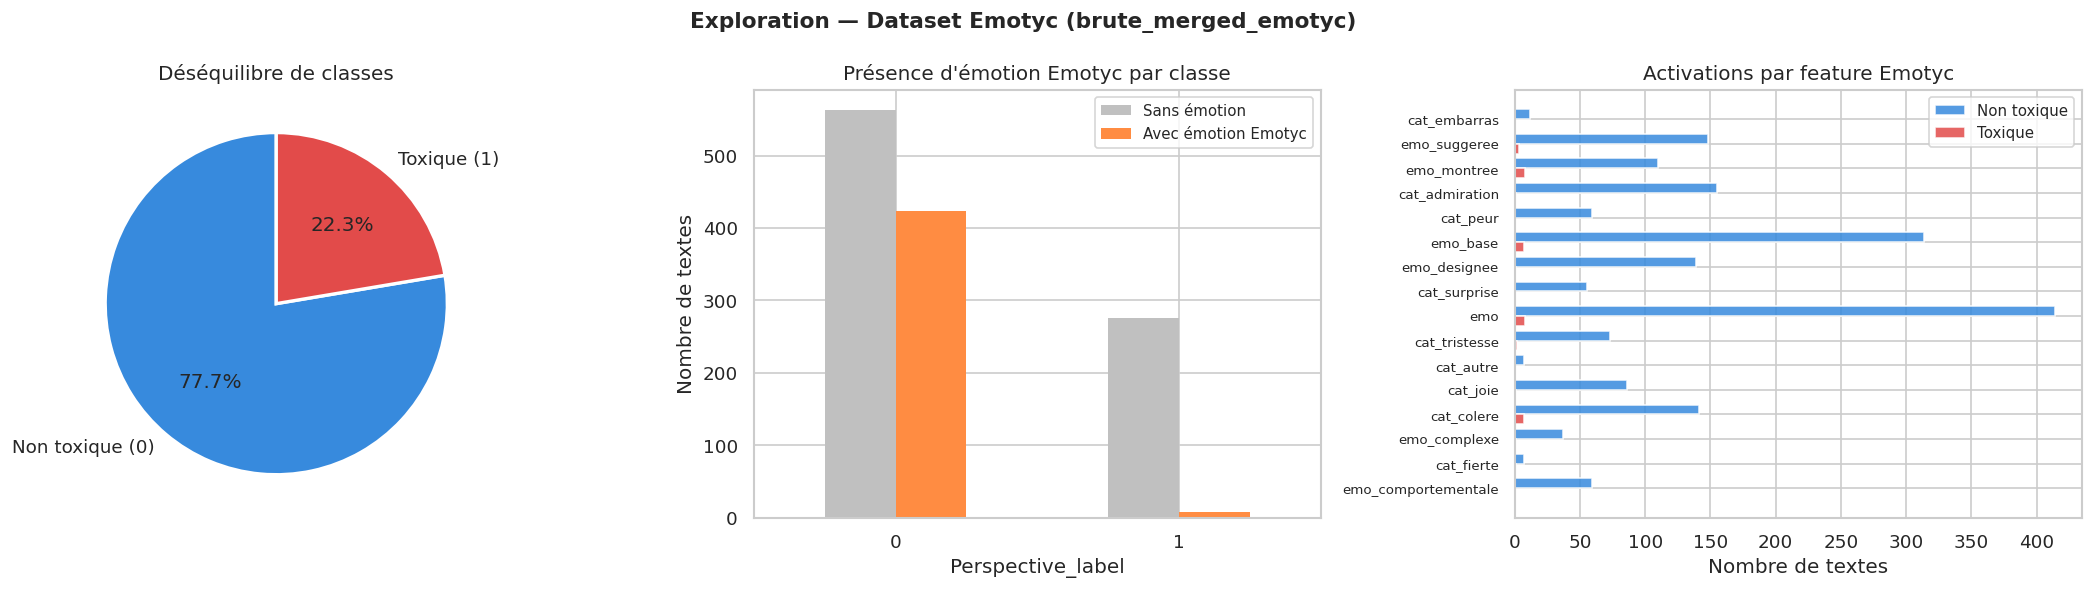


⚠️  Note : seulement 8 textes toxiques sur 284 ont une émotion Emotyc détectée
   → signal encore plus faible côté toxique que dans la version Emotion (3/284)
   → mais la couverture globale est meilleure : 432 textes vs 304 pour Emotion


In [ ]:


EMO_COLS = [c for c in df_c.columns if c.startswith('avec_')]

print("=== Valeurs manquantes ===")
missing = df_c.isnull().sum()
print(missing[missing > 0])

print("\n=== Distribution des labels ===")
print(df_c['Perspective_label'].value_counts().sort_index())

# Textes avec au moins 1 feature emotyc active
df_c['has_emotyc'] = df_c[EMO_COLS].sum(axis=1) > 0
print("\n=== Présence d'une émotion Emotyc par classe ===")
print(pd.crosstab(df_c['Perspective_label'], df_c['has_emotyc'],
                  rownames=['Toxique'], colnames=['A une émotion Emotyc'], margins=True))

# Stats par feature
print("\n=== Activations par feature Emotyc ===")
stats = pd.DataFrame({
    'total'      : df_c[EMO_COLS].sum(),
    'pct_%'      : (df_c[EMO_COLS].sum() / len(df_c) * 100).round(1),
    'toxique'    : df_c[df_c['Perspective_label']==1][EMO_COLS].sum(),
    'non_toxique': df_c[df_c['Perspective_label']==0][EMO_COLS].sum(),
}).sort_values('total', ascending=False)
display(stats)

# ── Visualisation ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Exploration — Dataset Emotyc (brute_merged_emotyc)', fontsize=13, fontweight='bold')

# 1 Déséquilibre de classes
counts = df_c['Perspective_label'].value_counts()
axes[0].pie(counts, labels=['Non toxique (0)', 'Toxique (1)'],
            colors=['#378ADD', '#E24B4A'],
            autopct='%1.1f%%', startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[0].set_title('Déséquilibre de classes')

# 2 Présence émotion par classe (Emotyc vs Emotion)
emo_tab = pd.crosstab(df_c['Perspective_label'], df_c['has_emotyc'])
emo_tab.plot(kind='bar', ax=axes[1], color=['#C0C0C0', '#FF8C42'], edgecolor='none')
axes[1].set_title("Présence d'émotion Emotyc par classe")
axes[1].set_xlabel('Perspective_label')
axes[1].set_ylabel('Nombre de textes')
axes[1].tick_params(axis='x', rotation=0)
axes[1].legend(['Sans émotion', 'Avec émotion Emotyc'], fontsize=9)

# 3 Activations par feature (non-toxique vs toxique)
feat_names = [c.replace('avec_', '') for c in EMO_COLS]
x_pos = np.arange(len(EMO_COLS))
width = 0.4
axes[2].barh(x_pos + width/2,
             df_c[df_c['Perspective_label']==0][EMO_COLS].sum().values,
             width, label='Non toxique', color='#378ADD', alpha=0.85)
axes[2].barh(x_pos - width/2,
             df_c[df_c['Perspective_label']==1][EMO_COLS].sum().values,
             width, label='Toxique', color='#E24B4A', alpha=0.85)
axes[2].set_yticks(x_pos)
axes[2].set_yticklabels(feat_names, fontsize=8)
axes[2].set_title('Activations par feature Emotyc')
axes[2].set_xlabel('Nombre de textes')
axes[2].legend(fontsize=9)

plt.tight_layout()
plt.savefig('C_exploration_emotyc.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n⚠️  Note : seulement 8 textes toxiques sur 284 ont une émotion Emotyc détectée")
print("   → signal encore plus faible côté toxique que dans la version Emotion (3/284)")
print("   → mais la couverture globale est meilleure : 432 textes vs 304 pour Emotion")

In [ ]:

print(f"Shape initiale : {df_c.shape}")

df_c_clean = df_c[df_c['Perspective_label'].isin([0, 1])].copy()
df_c_clean = df_c_clean.dropna(subset=['text'])
print(f"Après suppression NaN + labels aberrants : {df_c_clean.shape}")

df_c_clean = df_c_clean.drop_duplicates(subset='text', keep='first')
print(f"Après déduplication                       : {df_c_clean.shape}")

BOT_PATTERN = r'(I am a bot|AutoModérateur|AutoModerator|performed automatically)'
df_c_clean = df_c_clean[~df_c_clean['text'].astype(str).str.contains(BOT_PATTERN, case=False, regex=True)]
print(f"Après suppression bots                    : {df_c_clean.shape}")

df_c_clean = df_c_clean[df_c_clean['text'].str.len() >= 3]
print(f"Après filtre < 3 chars                    : {df_c_clean.shape}")

df_c_clean['text_clean'] = df_c_clean['text'].apply(clean_text)  # même fonction que A et B

print(f"\n✅ Dataset Emotyc propre : {df_c_clean.shape}")
print(f"   Toxique     : {(df_c_clean['Perspective_label']==1).sum()}")
print(f"   Non toxique : {(df_c_clean['Perspective_label']==0).sum()}")
display(df_c_clean[['text_clean', 'Perspective_label'] + EMO_COLS[:4]].head())

Shape initiale : (1271, 23)
Après suppression NaN + labels aberrants : (1239, 23)
Après déduplication                       : (1236, 23)
Après suppression bots                    : (1232, 23)
Après filtre < 3 chars                    : (1232, 23)

✅ Dataset Emotyc propre : (1232, 24)
   Toxique     : 283
   Non toxique : 949


/tmp/ipykernel_1347/3584561988.py:15: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  df_c_clean = df_c_clean[~df_c_clean['text'].astype(str).str.contains(BOT_PATTERN, case=False, regex=True)]


,text_clean,Perspective_label,avec_emo_comportementale,avec_cat_fierte,avec_emo_complexe,avec_cat_colere
0,"C'est dingue, après tout ce temps, plus de 15 ans après son décès, les blagues sur sa mort me font toujours autant r...",0,1,0,0,0
1,"Plutôt d'accord pour les SAV, c'est le but même du forum que de poser des questions donc pas besoin de post.",0,0,0,0,0
2,"Bordel. J'avais tapé une longue réponse. Une fausse manip sur le téléphone, et hop, perdue à jamais. J'essaierai de ...",0,0,0,0,0
3,Non pas de problème de ce côté là heureusement !,0,0,0,0,0
4,"Les violences étaient clairement motivées par l'homophobie et la misogynie, pourtant je n'ai admis que j'étais trans...",0,0,0,0,0


Token indices sequence length is longer than the specified maximum sequence length for this model (839 > 512). Running this sequence through the model will result in indexing errors
/tmp/ipykernel_1347/3035286743.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=valid_c, x='Classe', y='n_tokens',


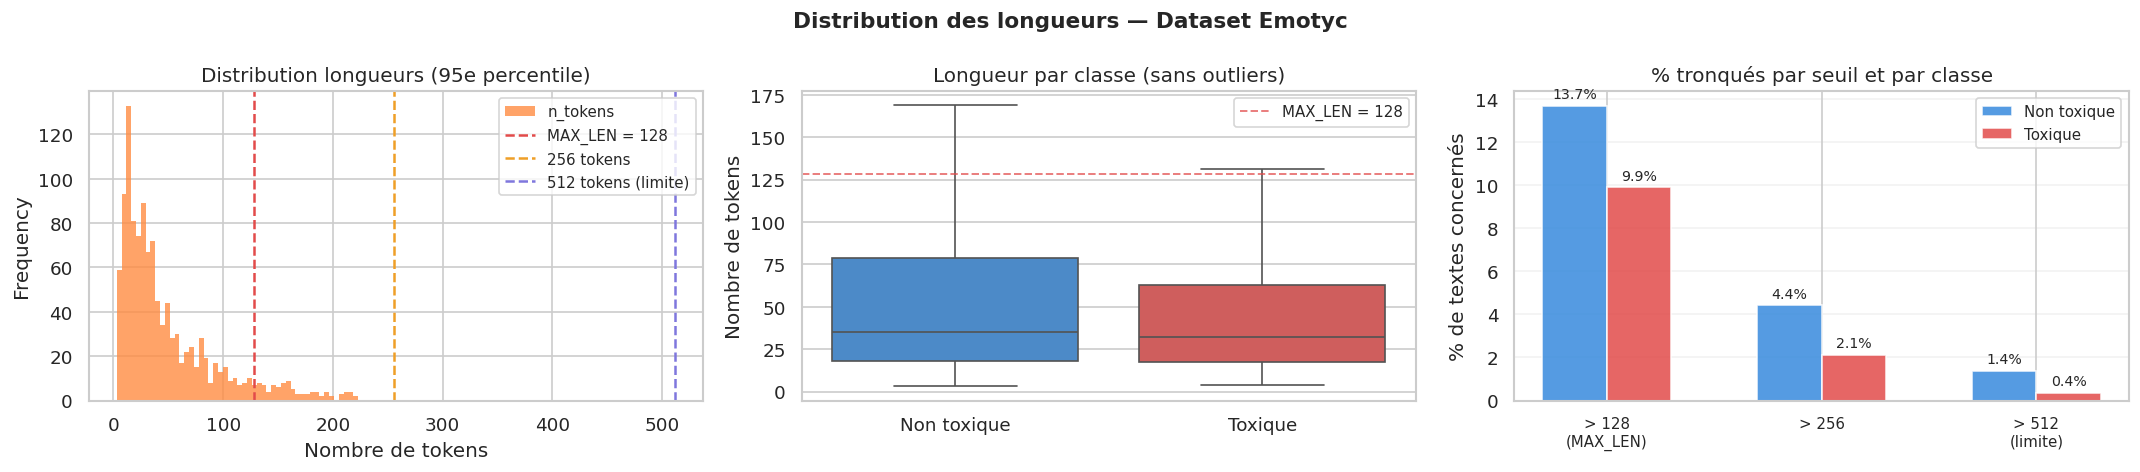

Médiane tokens      : 35
Textes > 128 tokens : 158 (12.8%)
Textes > 512 tokens : 14 (1.1%)


In [ ]:


_tokenizer = CamembertTokenizerFast.from_pretrained("camembert-base")

df_c_clean['n_tokens'] = df_c_clean['text_clean'].apply(
    lambda t: len(_tokenizer.encode(t, add_special_tokens=True))
)

fig, axes = plt.subplots(1, 3, figsize=(18, 4))
fig.suptitle('Distribution des longueurs — Dataset Emotyc', fontsize=13, fontweight='bold')

p95 = df_c_clean['n_tokens'].quantile(0.95)
df_c_clean[df_c_clean['n_tokens'] <= p95]['n_tokens'].plot(
    kind='hist', bins=50, ax=axes[0], color='#FF8C42', edgecolor='none', alpha=0.8)
axes[0].axvline(128, color='#E24B4A', lw=1.5, ls='--', label='MAX_LEN = 128')
axes[0].axvline(256, color='#EF9F27', lw=1.5, ls='--', label='256 tokens')
axes[0].axvline(512, color='#7F77DD', lw=1.5, ls='--', label='512 tokens (limite)')
axes[0].set_title('Distribution longueurs (95e percentile)')
axes[0].set_xlabel('Nombre de tokens')
axes[0].legend(fontsize=9)

valid_c = df_c_clean.copy()
valid_c['Classe'] = valid_c['Perspective_label'].map({0: 'Non toxique', 1: 'Toxique'})
sns.boxplot(data=valid_c, x='Classe', y='n_tokens',
            palette={'Non toxique': '#378ADD', 'Toxique': '#E24B4A'},
            ax=axes[1], showfliers=False)
axes[1].axhline(128, color='#E24B4A', lw=1.2, ls='--', alpha=0.7, label='MAX_LEN = 128')
axes[1].set_title('Longueur par classe (sans outliers)')
axes[1].set_ylabel('Nombre de tokens')
axes[1].set_xlabel('')
axes[1].legend(fontsize=9)

seuils   = [128, 256, 512]
labels_s = ['> 128\n(MAX_LEN)', '> 256', '> 512\n(limite)']
x_pos    = np.arange(len(seuils))
width    = 0.3
pct_0 = [100*(valid_c[valid_c['Classe']=='Non toxique']['n_tokens'] > s).mean() for s in seuils]
pct_1 = [100*(valid_c[valid_c['Classe']=='Toxique'   ]['n_tokens'] > s).mean() for s in seuils]
b0 = axes[2].bar(x_pos - width/2, pct_0, width, label='Non toxique', color='#378ADD', alpha=0.85)
b1 = axes[2].bar(x_pos + width/2, pct_1, width, label='Toxique',     color='#E24B4A', alpha=0.85)
for bar, v in [(b, val) for bars, vals in [(b0,pct_0),(b1,pct_1)] for b,val in zip(bars,vals)]:
    axes[2].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.2,
                 f'{v:.1f}%', ha='center', va='bottom', fontsize=8.5)
axes[2].set_xticks(x_pos)
axes[2].set_xticklabels(labels_s, fontsize=9)
axes[2].set_title('% tronqués par seuil et par classe')
axes[2].set_ylabel('% de textes concernés')
axes[2].legend(fontsize=9)
axes[2].grid(axis='y', alpha=0.25)

plt.tight_layout()
plt.savefig('C_token_dist.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Médiane tokens      : {df_c_clean['n_tokens'].median():.0f}")
print(f"Textes > 128 tokens : {(df_c_clean['n_tokens'] > 128).sum()} ({100*(df_c_clean['n_tokens'] > 128).mean():.1f}%)")
print(f"Textes > 512 tokens : {(df_c_clean['n_tokens'] > 512).sum()} ({100*(df_c_clean['n_tokens'] > 512).mean():.1f}%)")

In [ ]:


EMO_COLS = [c for c in df_c_clean.columns if c.startswith('avec_')]

# Les features sont déjà en 0/1 — on les extrait directement
X_emotyc = df_c_clean[EMO_COLS].values
y_c      = df_c_clean['Perspective_label'].values

print(f"Features Emotyc ({len(EMO_COLS)}) : {EMO_COLS}")
print(f"Shape X_emotyc : {X_emotyc.shape}")
print(f"Densité (lignes avec ≥1 feature active) : {(X_emotyc.sum(axis=1) > 0).sum()} / {len(X_emotyc)}")
print()

# Vérification : même ordre de textes que A et B ?
# On recalcule les embeddings sur df_c_clean (même pipeline)
print("⚠️  Les embeddings CamemBERT seront recalculés sur df_c_clean")
print("   (même textes que A/B après preprocessing — vérification ci-dessous)")
print(f"   df_clean shape  : {df_clean.shape}")
print(f"   df_c_clean shape: {df_c_clean.shape}")

Features Emotyc (16) : ['avec_emo_comportementale', 'avec_cat_fierte', 'avec_emo_complexe', 'avec_cat_colere', 'avec_cat_joie', 'avec_cat_autre', 'avec_cat_tristesse', 'avec_emo', 'avec_cat_surprise', 'avec_emo_designee', 'avec_emo_base', 'avec_cat_peur', 'avec_cat_admiration', 'avec_emo_montree', 'avec_emo_suggeree', 'avec_cat_embarras']
Shape X_emotyc : (1232, 16)
Densité (lignes avec ≥1 feature active) : 421 / 1232

⚠️  Les embeddings CamemBERT seront recalculés sur df_c_clean
   (même textes que A/B après preprocessing — vérification ci-dessous)
   df_clean shape  : (1232, 13)
   df_c_clean shape: (1232, 25)


In [ ]:


texts_AB = set(df_clean['text_clean'].tolist())
texts_C  = set(df_c_clean['text_clean'].tolist())

if texts_AB == texts_C:
    print("✅ Textes identiques à A/B — réutilisation de X_emb")
    # Aligner dans le même ordre que df_c_clean
    text_to_emb = dict(zip(df_clean['text_clean'].tolist(),
                           [X_emb[i] for i in range(len(X_emb))]))
    X_emb_c = np.array([text_to_emb[t] for t in df_c_clean['text_clean'].tolist()])
else:
    print("⚠️  Textes différents — recalcul des embeddings pour Version C")
    model_c = CamembertModel.from_pretrained(MODEL_NAME).to(DEVICE)
    model_c.eval()
    for param in model_c.parameters():
        param.requires_grad = False
    X_emb_c = get_embeddings(df_c_clean['text_clean'].tolist())
    del model_c
    torch.cuda.empty_cache()

# Construction X_C = embeddings + features Emotyc
X_C = np.hstack([X_emb_c, X_emotyc])
print(f"\nShape X_emb_c : {X_emb_c.shape}")
print(f"Shape X_emotyc : {X_emotyc.shape}")
print(f"Shape X_C (concat) : {X_C.shape}")

# Split
X_C_train, X_C_test, y_C_train, y_C_test = train_test_split(
    X_C, y_c, test_size=0.2, random_state=42, stratify=y_c
)

# SMOTE
smote_c = SMOTE(random_state=42)
X_C_train_sm, y_C_train_sm = smote_c.fit_resample(X_C_train, y_C_train)

print(f"\nTrain : {X_C_train.shape[0]} | Test : {X_C_test.shape[0]}")
print(f"Train SMOTE : {X_C_train_sm.shape[0]} | répartition : {dict(zip(*np.unique(y_C_train_sm, return_counts=True)))}")

✅ Textes identiques à A/B — réutilisation de X_emb

Shape X_emb_c : (1232, 768)
Shape X_emotyc : (1232, 16)
Shape X_C (concat) : (1232, 784)

Train : 985 | Test : 247
Train SMOTE : 1518 | répartition : {np.int64(0): np.int64(759), np.int64(1): np.int64(759)}


In [ ]:


clf_C_v1 = make_pipeline(
    StandardScaler(),
    LogisticRegression(max_iter=2000, solver='lbfgs', random_state=42)
)
clf_C_v1.fit(X_C_train_sm, y_C_train_sm)
y_pred_C_v1, metrics_C_v1 = evaluate_model(
    "LR + SMOTE", clf_C_v1, X_C_test, y_C_test, version_label="C"
)


  [C] LR + SMOTE
  Accuracy  = 0.7976
  Precision = 0.5467
  Recall    = 0.7193
  F1-score  = 0.6212
                 precision    recall  f1-score   support

Non-toxique (0)       0.91      0.82      0.86       190
    Toxique (1)       0.55      0.72      0.62        57

       accuracy                           0.80       247
      macro avg       0.73      0.77      0.74       247
   weighted avg       0.82      0.80      0.81       247



In [ ]:


clf_C_v2 = make_pipeline(
    StandardScaler(),
    LogisticRegression(max_iter=2000, class_weight='balanced',
                       solver='lbfgs', random_state=42)
)
clf_C_v2.fit(X_C_train, y_C_train)
y_pred_C_v2, metrics_C_v2 = evaluate_model(
    "LR + class_weight", clf_C_v2, X_C_test, y_C_test, version_label="C"
)


  [C] LR + class_weight
  Accuracy  = 0.8057
  Precision = 0.5600
  Recall    = 0.7368
  F1-score  = 0.6364
                 precision    recall  f1-score   support

Non-toxique (0)       0.91      0.83      0.87       190
    Toxique (1)       0.56      0.74      0.64        57

       accuracy                           0.81       247
      macro avg       0.74      0.78      0.75       247
   weighted avg       0.83      0.81      0.81       247



In [ ]:


clf_C_v3 = make_pipeline(
    StandardScaler(),
    SVC(kernel='rbf', class_weight='balanced', probability=True,
        C=1.0, gamma='scale', random_state=42)
)
clf_C_v3.fit(X_C_train, y_C_train)
y_pred_C_v3, metrics_C_v3 = evaluate_model(
    "SVM + class_weight", clf_C_v3, X_C_test, y_C_test, version_label="C"
)


  [C] SVM + class_weight
  Accuracy  = 0.9028
  Precision = 0.8367
  Recall    = 0.7193
  F1-score  = 0.7736
                 precision    recall  f1-score   support

Non-toxique (0)       0.92      0.96      0.94       190
    Toxique (1)       0.84      0.72      0.77        57

       accuracy                           0.90       247
      macro avg       0.88      0.84      0.86       247
   weighted avg       0.90      0.90      0.90       247



In [ ]:


clf_C_v4 = make_pipeline(
    StandardScaler(),
    SVC(kernel='rbf', probability=True, C=1.0, gamma='scale', random_state=42)
)
clf_C_v4.fit(X_C_train_sm, y_C_train_sm)
y_pred_C_v4, metrics_C_v4 = evaluate_model(
    "SVM + SMOTE", clf_C_v4, X_C_test, y_C_test, version_label="C"
)


  [C] SVM + SMOTE
  Accuracy  = 0.8988
  Precision = 0.9000
  Recall    = 0.6316
  F1-score  = 0.7423
                 precision    recall  f1-score   support

Non-toxique (0)       0.90      0.98      0.94       190
    Toxique (1)       0.90      0.63      0.74        57

       accuracy                           0.90       247
      macro avg       0.90      0.81      0.84       247
   weighted avg       0.90      0.90      0.89       247



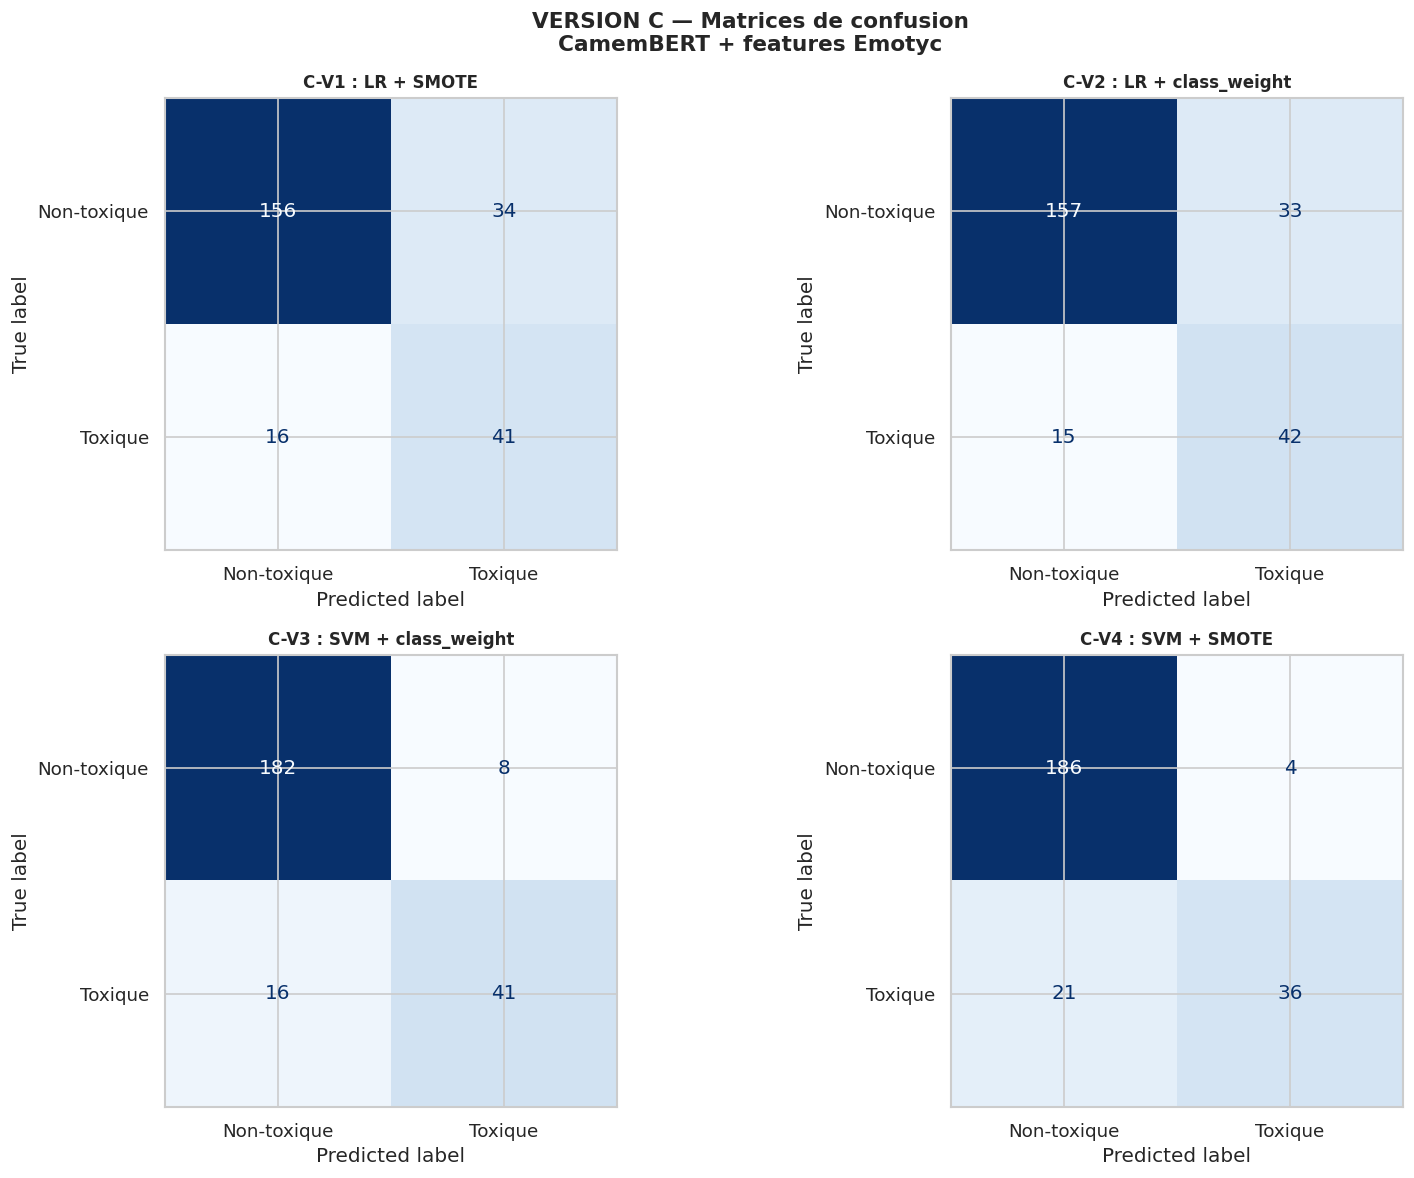

In [ ]:


fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('VERSION C — Matrices de confusion\nCamemBERT + features Emotyc',
             fontsize=13, fontweight='bold')
axes = axes.flatten()

for ax, (y_pred, title) in zip(axes, [
    (y_pred_C_v1, "C-V1 : LR + SMOTE"),
    (y_pred_C_v2, "C-V2 : LR + class_weight"),
    (y_pred_C_v3, "C-V3 : SVM + class_weight"),
    (y_pred_C_v4, "C-V4 : SVM + SMOTE"),
]):
    plot_confusion(y_C_test, y_pred, title, ax)

plt.tight_layout()
plt.savefig('C_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

⏳ C-V1 : LR + SMOTE...
⏳ C-V2 : LR + class_weight...
⏳ C-V3 : SVM + class_weight...
⏳ C-V4 : SVM + SMOTE...


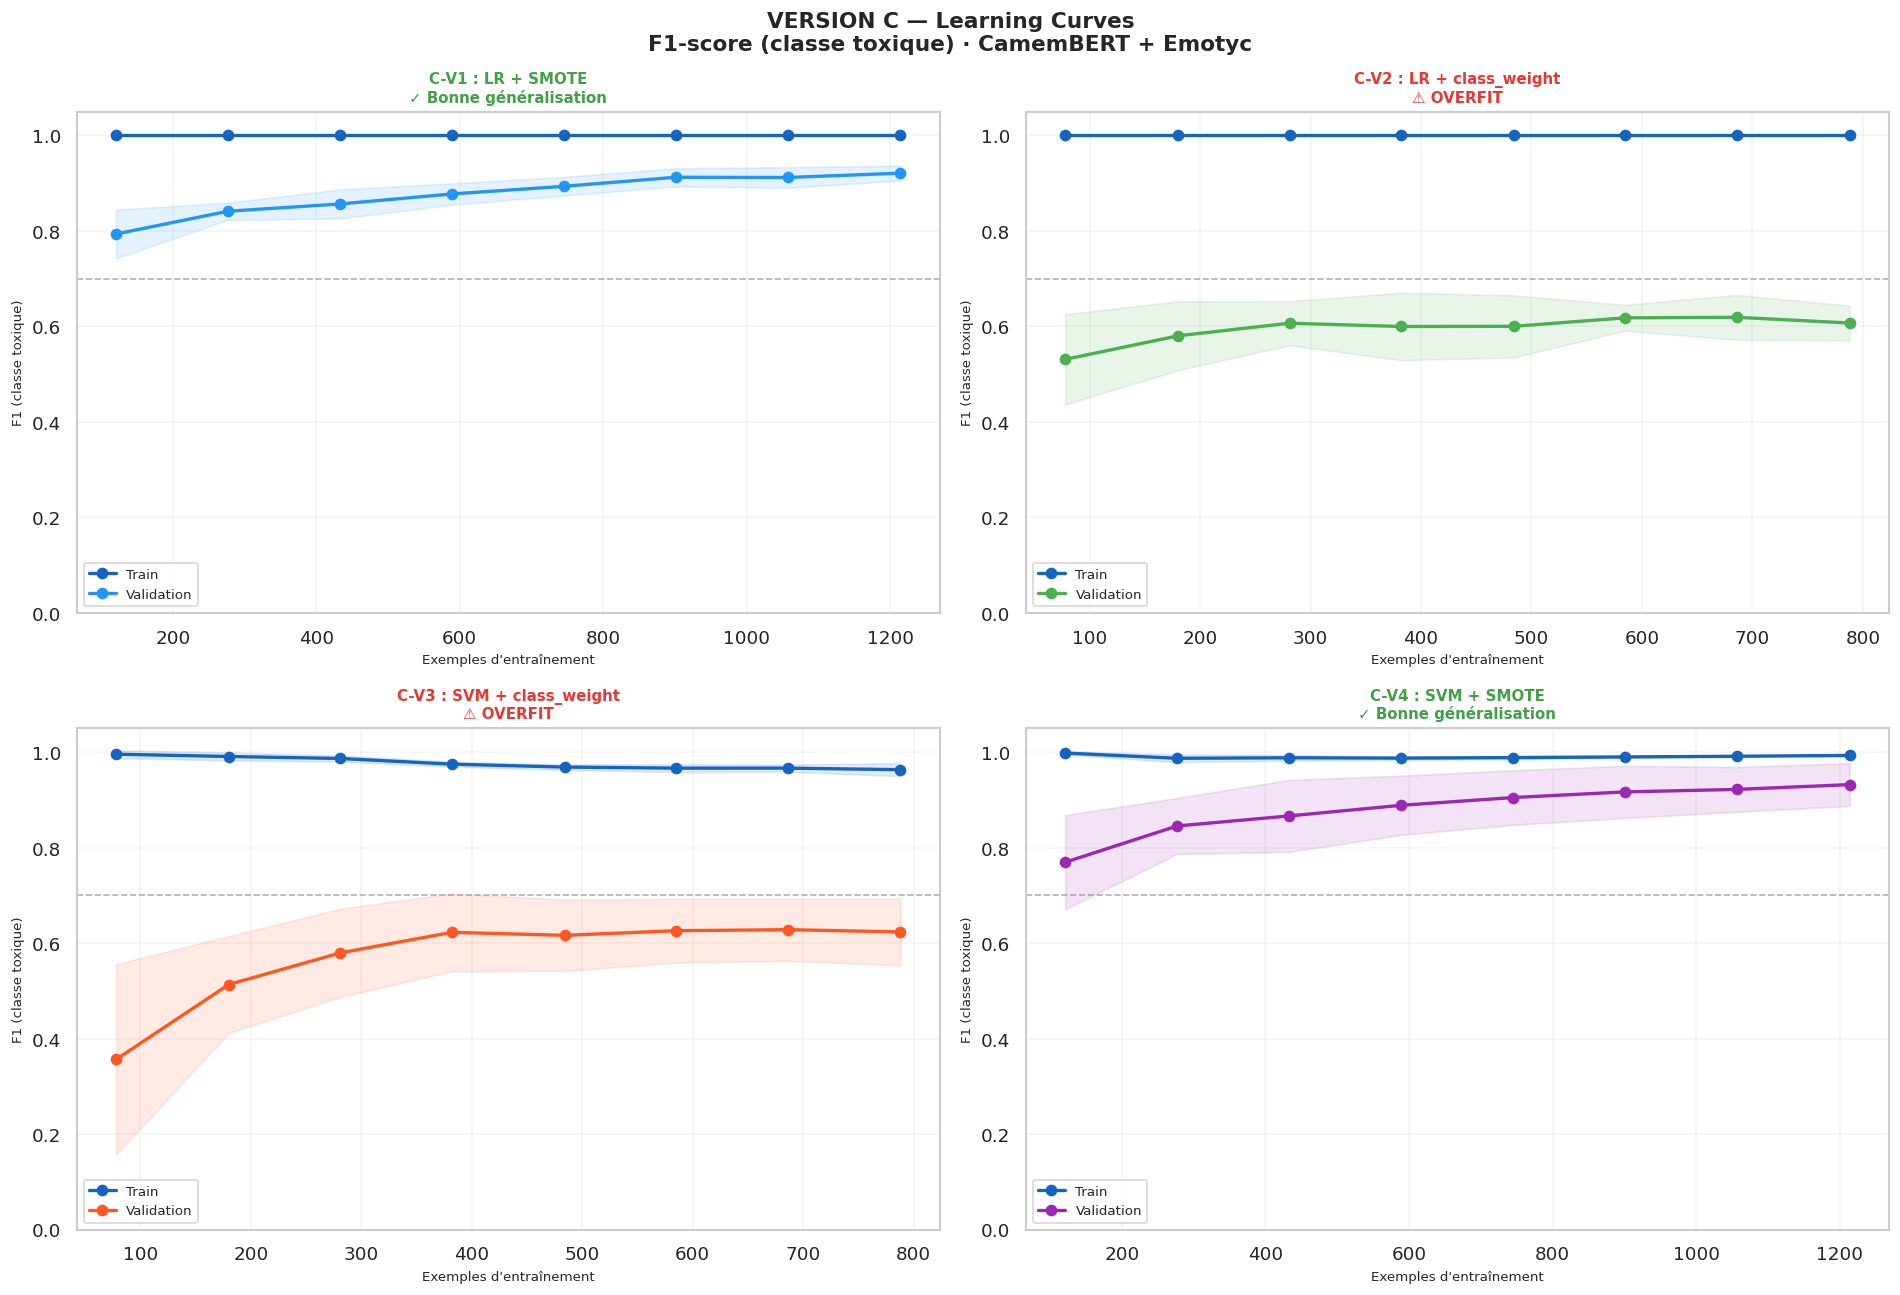

✅ Learning curves Version C sauvegardées


In [ ]:


fig, axes = plt.subplots(2, 2, figsize=(16, 11))
fig.suptitle('VERSION C — Learning Curves\nF1-score (classe toxique) · CamemBERT + Emotyc',
             fontsize=13, fontweight='bold')
axes = axes.flatten()

for ax, (clf, X_tr, y_tr, title, color) in zip(axes, [
    (clf_C_v1, X_C_train_sm, y_C_train_sm, "C-V1 : LR + SMOTE",        "#2196F3"),
    (clf_C_v2, X_C_train,    y_C_train,    "C-V2 : LR + class_weight",  "#4CAF50"),
    (clf_C_v3, X_C_train,    y_C_train,    "C-V3 : SVM + class_weight", "#FF5722"),
    (clf_C_v4, X_C_train_sm, y_C_train_sm, "C-V4 : SVM + SMOTE",       "#9C27B0"),
]):
    print(f"⏳ {title}...")
    plot_learning_curve(clf, X_tr, y_tr, title, ax, color)

plt.tight_layout()
plt.savefig('C_learning_curves.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print("✅ Learning curves Version C sauvegardées")


=== Comparaison finale A / B / C ===


,F1 — A (sans émo),F1 — B (Emotion),F1 — C (Emotyc),Δ B−A,Δ C−A,Δ C−B
Variante,,,,,,
LR + SMOTE,0.5469,0.6032,0.6212,0.0563,0.0743,0.0180
LR + class_weight,0.5556,0.5781,0.6364,0.0226,0.0808,0.0582
SVM + class_weight,0.7091,0.7156,0.7736,0.0065,0.0645,0.0580
SVM + SMOTE,0.6602,0.7129,0.7423,0.0527,0.0821,0.0294


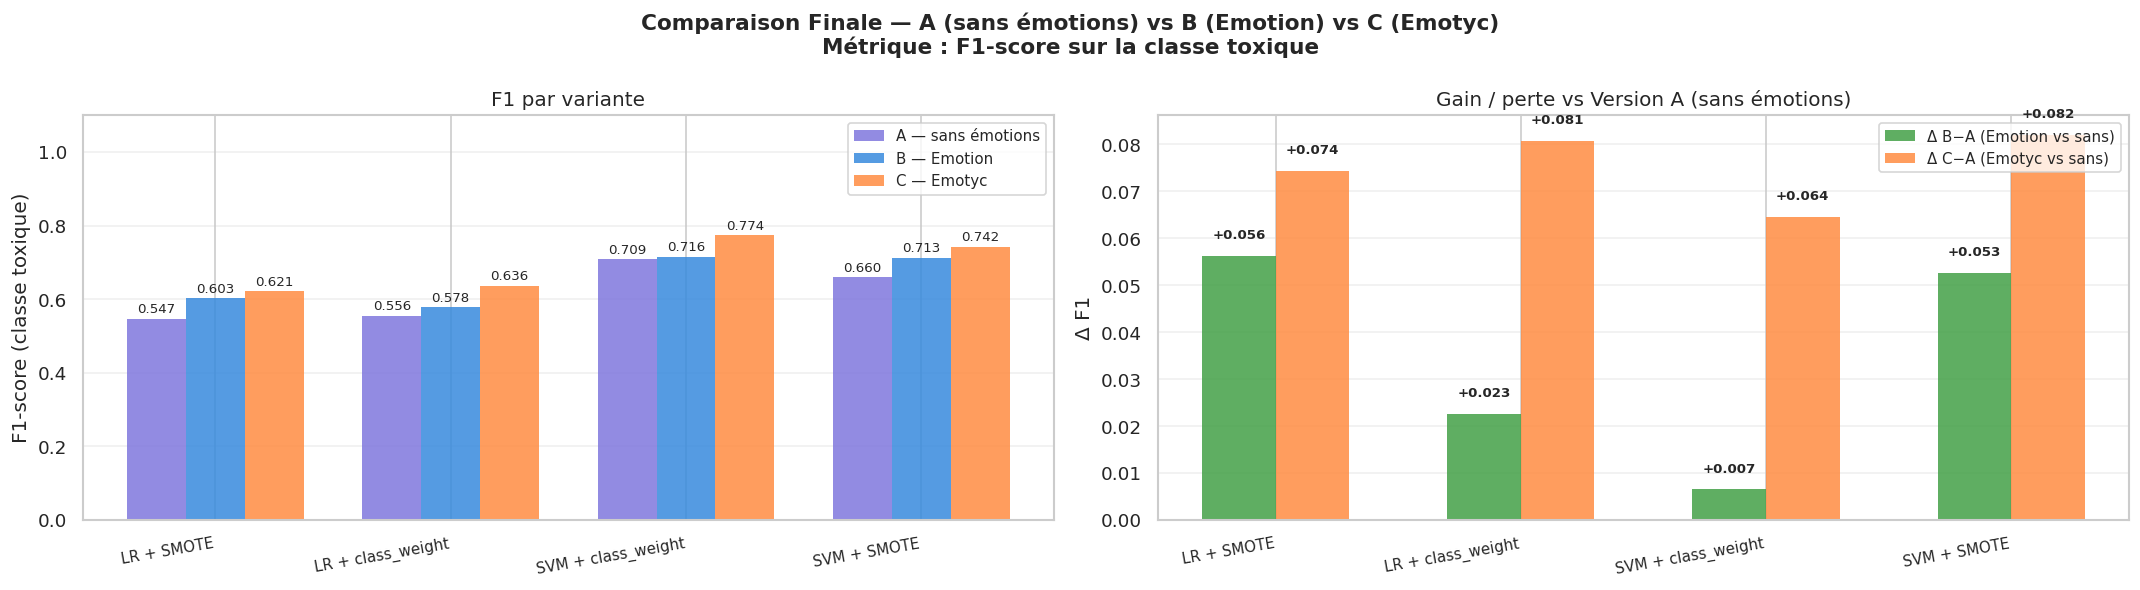

✅ Graphe de comparaison finale A/B/C sauvegardé


In [ ]:


variantes  = ['LR + SMOTE', 'LR + class_weight', 'SVM + class_weight', 'SVM + SMOTE']
f1_A = [metrics_A_v1['f1'], metrics_A_v2['f1'], metrics_A_v3['f1'], metrics_A_v4['f1']]
f1_B = [metrics_B_v1['f1'], metrics_B_v2['f1'], metrics_B_v3['f1'], metrics_B_v4['f1']]
f1_C = [metrics_C_v1['f1'], metrics_C_v2['f1'], metrics_C_v3['f1'], metrics_C_v4['f1']]

# Tableau récapitulatif
df_abc = pd.DataFrame({
    'Variante'            : variantes,
    'F1 — A (sans émo)'  : f1_A,
    'F1 — B (Emotion)'   : f1_B,
    'F1 — C (Emotyc)'    : f1_C,
    'Δ B−A'              : [b-a for a,b in zip(f1_A, f1_B)],
    'Δ C−A'              : [c-a for a,c in zip(f1_A, f1_C)],
    'Δ C−B'              : [c-b for b,c in zip(f1_B, f1_C)],
}).set_index('Variante')

print("\n=== Comparaison finale A / B / C ===")
display(df_abc.round(4))

# Graphe 1 : F1 côte à côte par variante
x_pos = np.arange(len(variantes))
width = 0.25

fig, axes = plt.subplots(1, 2, figsize=(18, 5))
fig.suptitle('Comparaison Finale — A (sans émotions) vs B (Emotion) vs C (Emotyc)\n'
             'Métrique : F1-score sur la classe toxique',
             fontsize=13, fontweight='bold')

for vals, label, color, offset in [
    (f1_A, 'A — sans émotions', '#7F77DD', -width),
    (f1_B, 'B — Emotion',       '#378ADD',  0),
    (f1_C, 'C — Emotyc',        '#FF8C42',  width),
]:
    bars = axes[0].bar(x_pos + offset, vals, width, label=label,
                       color=color, alpha=0.85, edgecolor='none')
    for bar, v in zip(bars, vals):
        axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.008,
                     f'{v:.3f}', ha='center', va='bottom', fontsize=8)

axes[0].set_xticks(x_pos)
axes[0].set_xticklabels(variantes, rotation=10, ha='right', fontsize=9)
axes[0].set_ylim(0, 1.1)
axes[0].set_ylabel('F1-score (classe toxique)')
axes[0].set_title('F1 par variante')
axes[0].legend(fontsize=9)
axes[0].grid(axis='y', alpha=0.3)

# Graphe 2 : Deltas Δ B−A et Δ C−A
delta_BA = [b-a for a,b in zip(f1_A, f1_B)]
delta_CA = [c-a for a,c in zip(f1_A, f1_C)]

x2 = np.arange(len(variantes))
w2 = 0.3

b1 = axes[1].bar(x2 - w2/2, delta_BA, w2, label='Δ B−A (Emotion vs sans)',
                  color=['#43A047' if d > 0 else '#e53935' for d in delta_BA],
                  alpha=0.85, edgecolor='none')
b2 = axes[1].bar(x2 + w2/2, delta_CA, w2, label='Δ C−A (Emotyc vs sans)',
                  color=['#FF8C42' if d > 0 else '#b71c1c' for d in delta_CA],
                  alpha=0.85, edgecolor='none')

axes[1].axhline(0, color='black', lw=0.8, ls='--')
for bar, v in [(b, val) for bars, vals in [(b1,delta_BA),(b2,delta_CA)]
               for b, val in zip(bars, vals)]:
    signe = '+' if v >= 0 else ''
    axes[1].text(bar.get_x()+bar.get_width()/2,
                 v + 0.003*np.sign(v) if v != 0 else 0.003,
                 f'{signe}{v:.3f}', ha='center',
                 va='bottom' if v >= 0 else 'top', fontsize=8, fontweight='bold')

axes[1].set_xticks(x2)
axes[1].set_xticklabels(variantes, rotation=10, ha='right', fontsize=9)
axes[1].set_ylabel('Δ F1')
axes[1].set_title('Gain / perte vs Version A (sans émotions)')
axes[1].legend(fontsize=9)
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('comparaison_finale_ABC.png', dpi=180, bbox_inches='tight', facecolor='white')
plt.show()
print("✅ Graphe de comparaison finale A/B/C sauvegardé")

# **3.Redit_emotion_emotic**

In [ ]:

texts_B = df_clean['text_clean'].tolist()
texts_C = df_c_clean['text_clean'].tolist()

if texts_B == texts_C:
    print("✅ Textes identiques entre B et C — concaténation directe")
    X_emotion_D = X_emotion   # (n, 23)
    X_emotyc_D  = X_emotyc    # (n, 16)
else:
    print("⚠️  Ordre différent — réalignement sur les textes de df_clean")
    text_to_emotyc = dict(zip(df_c_clean['text_clean'].tolist(),
                               X_emotyc))
    X_emotyc_D = np.array([text_to_emotyc[t] for t in texts_B])

# Concaténation : embeddings + Emotion + Emotyc
X_D = np.hstack([X_emb, X_emotion_D, X_emotyc_D])
y_D = y  # mêmes labels

print(f"\nDimensions :")
print(f"  X_emb      : {X_emb.shape}      ← CamemBERT")
print(f"  X_emotion  : {X_emotion_D.shape}       ← Emotion (MLB 23 catégories)")
print(f"  X_emotyc   : {X_emotyc_D.shape}       ← Emotyc  (16 features binaires)")
print(f"  X_D total  : {X_D.shape}     ← tout combiné")
print(f"\nFeatures émotionnelles totales : {X_emotion_D.shape[1] + X_emotyc_D.shape[1]} (23 + 16)")

✅ Textes identiques entre B et C — concaténation directe

Dimensions :
  X_emb      : (1232, 768)      ← CamemBERT
  X_emotion  : (1232, 23)       ← Emotion (MLB 23 catégories)
  X_emotyc   : (1232, 16)       ← Emotyc  (16 features binaires)
  X_D total  : (1232, 807)     ← tout combiné

Features émotionnelles totales : 39 (23 + 16)


In [ ]:


X_D_train, X_D_test, y_D_train, y_D_test = train_test_split(
    X_D, y_D, test_size=0.2, random_state=42, stratify=y_D
)

smote_d = SMOTE(random_state=42)
X_D_train_sm, y_D_train_sm = smote_d.fit_resample(X_D_train, y_D_train)

print(f"Train : {X_D_train.shape[0]} | Test : {X_D_test.shape[0]}")
print(f"Train SMOTE : {X_D_train_sm.shape[0]} | "
      f"répartition : {dict(zip(*np.unique(y_D_train_sm, return_counts=True)))}")

Train : 985 | Test : 247
Train SMOTE : 1518 | répartition : {np.int64(0): np.int64(759), np.int64(1): np.int64(759)}


In [ ]:

clf_D_v1 = make_pipeline(
    StandardScaler(),
    LogisticRegression(max_iter=2000, solver='lbfgs', random_state=42)
)
clf_D_v1.fit(X_D_train_sm, y_D_train_sm)
y_pred_D_v1, metrics_D_v1 = evaluate_model(
    "LR + SMOTE", clf_D_v1, X_D_test, y_D_test, version_label="D"
)


  [D] LR + SMOTE
  Accuracy  = 0.8178
  Precision = 0.5811
  Recall    = 0.7544
  F1-score  = 0.6565
                 precision    recall  f1-score   support

Non-toxique (0)       0.92      0.84      0.88       190
    Toxique (1)       0.58      0.75      0.66        57

       accuracy                           0.82       247
      macro avg       0.75      0.80      0.77       247
   weighted avg       0.84      0.82      0.83       247



In [ ]:


clf_D_v2 = make_pipeline(
    StandardScaler(),
    LogisticRegression(max_iter=2000, class_weight='balanced',
                       solver='lbfgs', random_state=42)
)
clf_D_v2.fit(X_D_train, y_D_train)
y_pred_D_v2, metrics_D_v2 = evaluate_model(
    "LR + class_weight", clf_D_v2, X_D_test, y_D_test, version_label="D"
)


  [D] LR + class_weight
  Accuracy  = 0.8219
  Precision = 0.5867
  Recall    = 0.7719
  F1-score  = 0.6667
                 precision    recall  f1-score   support

Non-toxique (0)       0.92      0.84      0.88       190
    Toxique (1)       0.59      0.77      0.67        57

       accuracy                           0.82       247
      macro avg       0.76      0.80      0.77       247
   weighted avg       0.85      0.82      0.83       247



In [ ]:


clf_D_v3 = make_pipeline(
    StandardScaler(),
    SVC(kernel='rbf', class_weight='balanced', probability=True,
        C=1.0, gamma='scale', random_state=42)
)
clf_D_v3.fit(X_D_train, y_D_train)
y_pred_D_v3, metrics_D_v3 = evaluate_model(
    "SVM + class_weight", clf_D_v3, X_D_test, y_D_test, version_label="D"
)


  [D] SVM + class_weight
  Accuracy  = 0.8947
  Precision = 0.8039
  Recall    = 0.7193
  F1-score  = 0.7593
                 precision    recall  f1-score   support

Non-toxique (0)       0.92      0.95      0.93       190
    Toxique (1)       0.80      0.72      0.76        57

       accuracy                           0.89       247
      macro avg       0.86      0.83      0.85       247
   weighted avg       0.89      0.89      0.89       247



In [ ]:


clf_D_v4 = make_pipeline(
    StandardScaler(),
    SVC(kernel='rbf', probability=True, C=1.0, gamma='scale', random_state=42)
)
clf_D_v4.fit(X_D_train_sm, y_D_train_sm)
y_pred_D_v4, metrics_D_v4 = evaluate_model(
    "SVM + SMOTE", clf_D_v4, X_D_test, y_D_test, version_label="D"
)


  [D] SVM + SMOTE
  Accuracy  = 0.8866
  Precision = 0.8372
  Recall    = 0.6316
  F1-score  = 0.7200
                 precision    recall  f1-score   support

Non-toxique (0)       0.90      0.96      0.93       190
    Toxique (1)       0.84      0.63      0.72        57

       accuracy                           0.89       247
      macro avg       0.87      0.80      0.82       247
   weighted avg       0.88      0.89      0.88       247



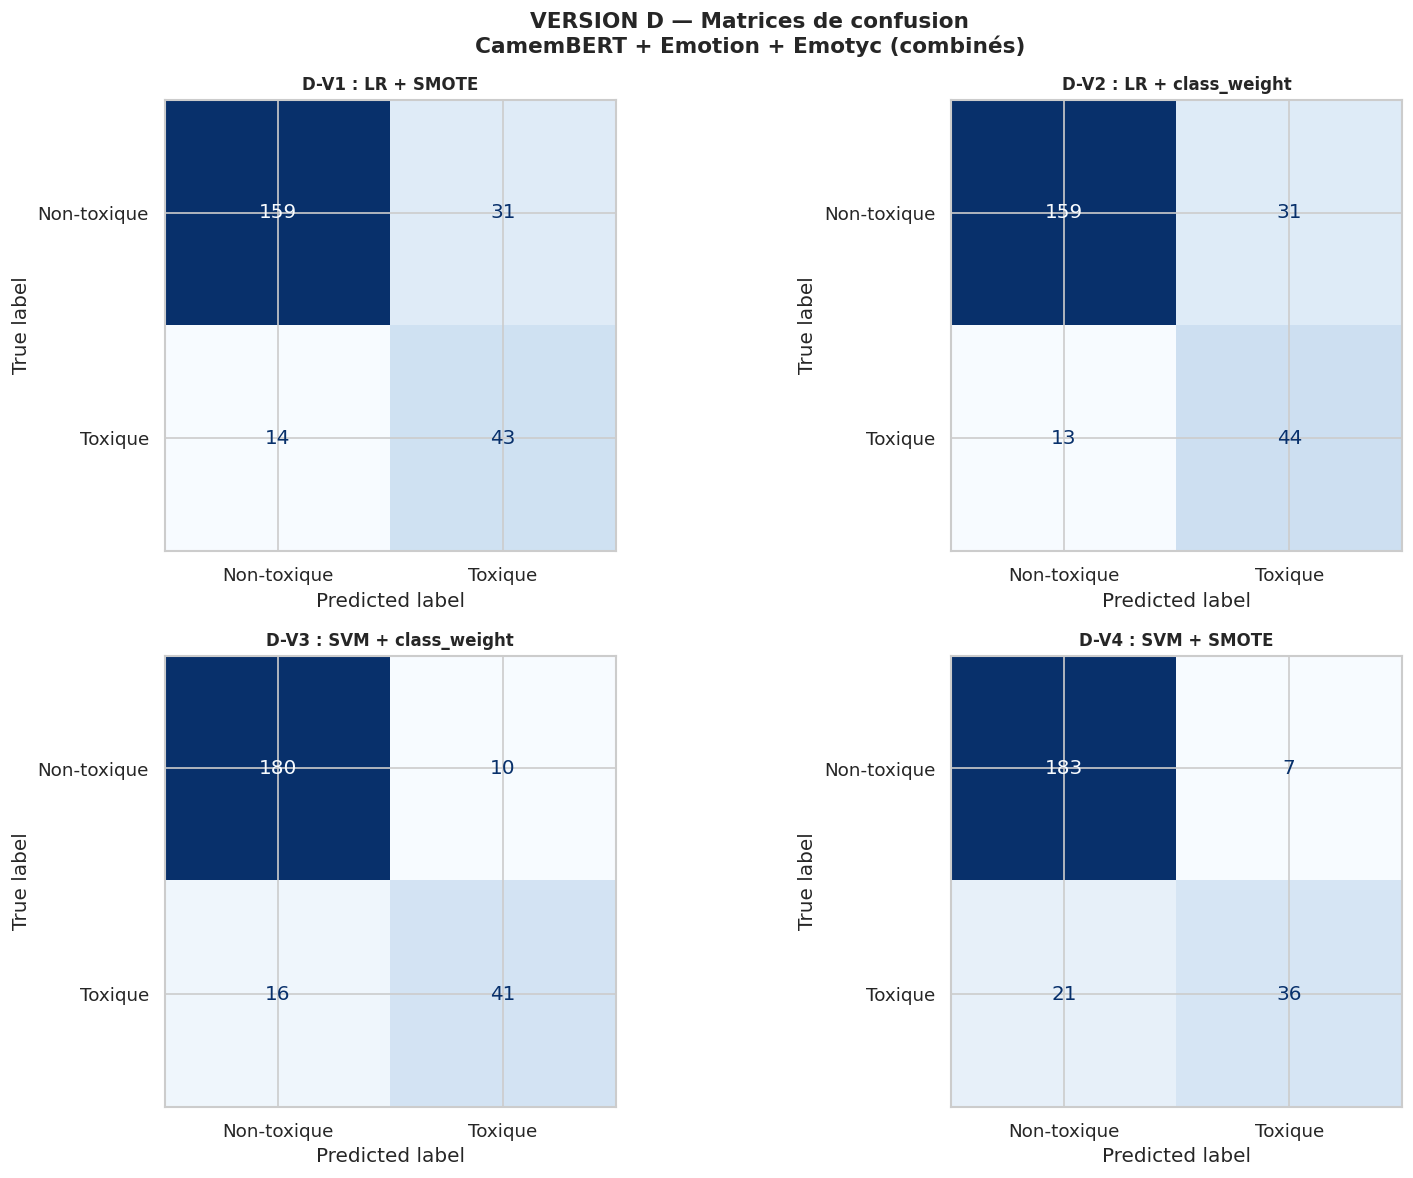

In [ ]:


fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('VERSION D — Matrices de confusion\n'
             'CamemBERT + Emotion + Emotyc (combinés)',
             fontsize=13, fontweight='bold')
axes = axes.flatten()

for ax, (y_pred, title) in zip(axes, [
    (y_pred_D_v1, "D-V1 : LR + SMOTE"),
    (y_pred_D_v2, "D-V2 : LR + class_weight"),
    (y_pred_D_v3, "D-V3 : SVM + class_weight"),
    (y_pred_D_v4, "D-V4 : SVM + SMOTE"),
]):
    plot_confusion(y_D_test, y_pred, title, ax)

plt.tight_layout()
plt.savefig('D_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

⏳ D-V1 : LR + SMOTE...
⏳ D-V2 : LR + class_weight...
⏳ D-V3 : SVM + class_weight...
⏳ D-V4 : SVM + SMOTE...


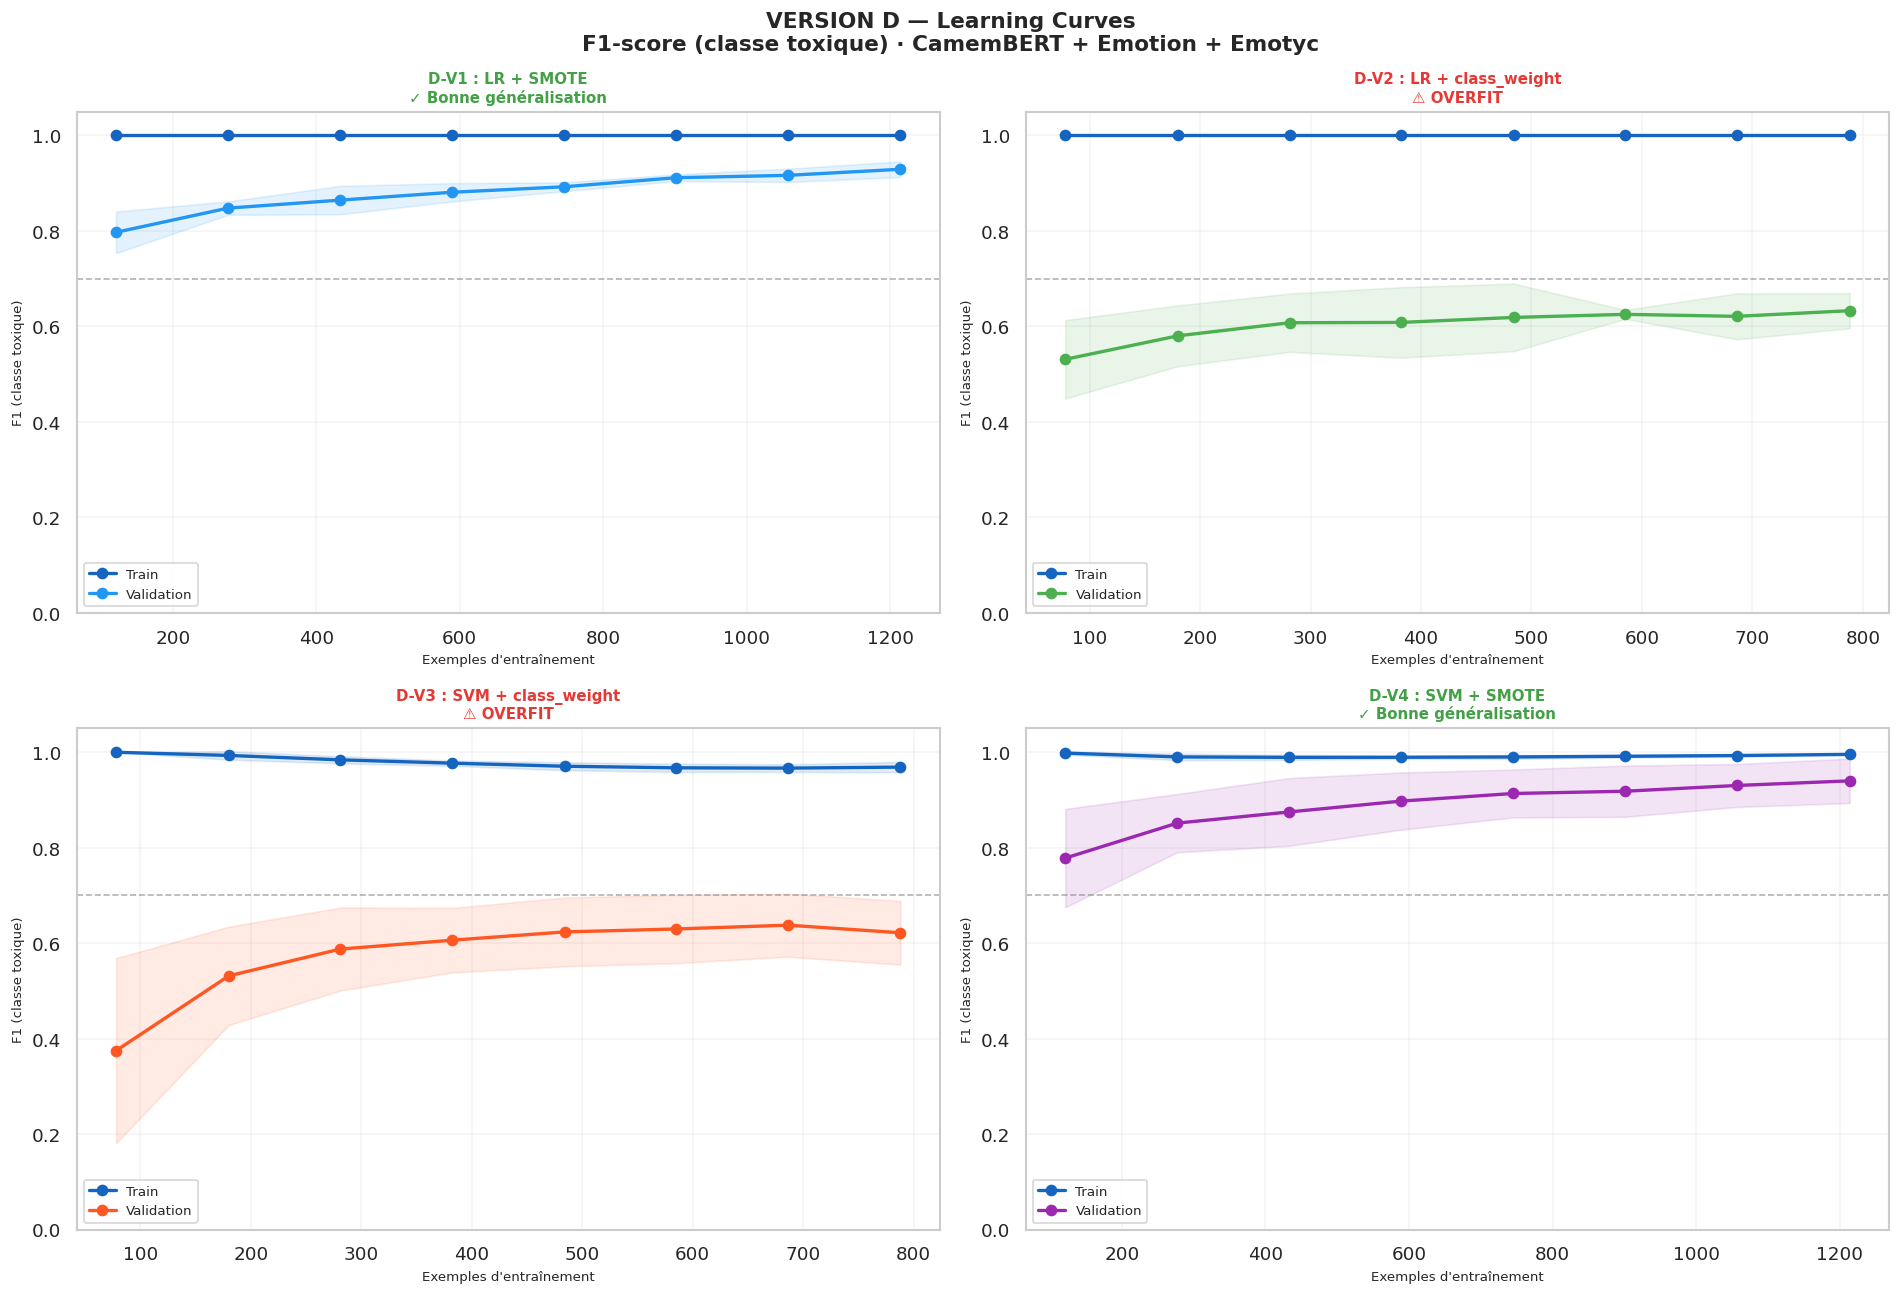

✅ Learning curves Version D sauvegardées


In [ ]:

fig, axes = plt.subplots(2, 2, figsize=(16, 11))
fig.suptitle('VERSION D — Learning Curves\n'
             'F1-score (classe toxique) · CamemBERT + Emotion + Emotyc',
             fontsize=13, fontweight='bold')
axes = axes.flatten()

for ax, (clf, X_tr, y_tr, title, color) in zip(axes, [
    (clf_D_v1, X_D_train_sm, y_D_train_sm, "D-V1 : LR + SMOTE",        "#2196F3"),
    (clf_D_v2, X_D_train,    y_D_train,    "D-V2 : LR + class_weight",  "#4CAF50"),
    (clf_D_v3, X_D_train,    y_D_train,    "D-V3 : SVM + class_weight", "#FF5722"),
    (clf_D_v4, X_D_train_sm, y_D_train_sm, "D-V4 : SVM + SMOTE",       "#9C27B0"),
]):
    print(f"⏳ {title}...")
    plot_learning_curve(clf, X_tr, y_tr, title, ax, color)

plt.tight_layout()
plt.savefig('D_learning_curves.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print("✅ Learning curves Version D sauvegardées")


=== Comparaison finale A / B / C / D ===


,A — sans émotions,B — Emotion,C — Emotyc,D — Emotion+Emotyc,Δ B−A,Δ C−A,Δ D−A,Δ D−B,Δ D−C
Variante,,,,,,,,,
LR + SMOTE,0.5469,0.6032,0.6212,0.6565,0.0563,0.0743,0.1096,0.0533,0.0353
LR + class_weight,0.5556,0.5781,0.6364,0.6667,0.0226,0.0808,0.1111,0.0885,0.0303
SVM + class_weight,0.7091,0.7156,0.7736,0.7593,0.0065,0.0645,0.0502,0.0437,-0.0143
SVM + SMOTE,0.6602,0.7129,0.7423,0.7200,0.0527,0.0821,0.0598,0.0071,-0.0223


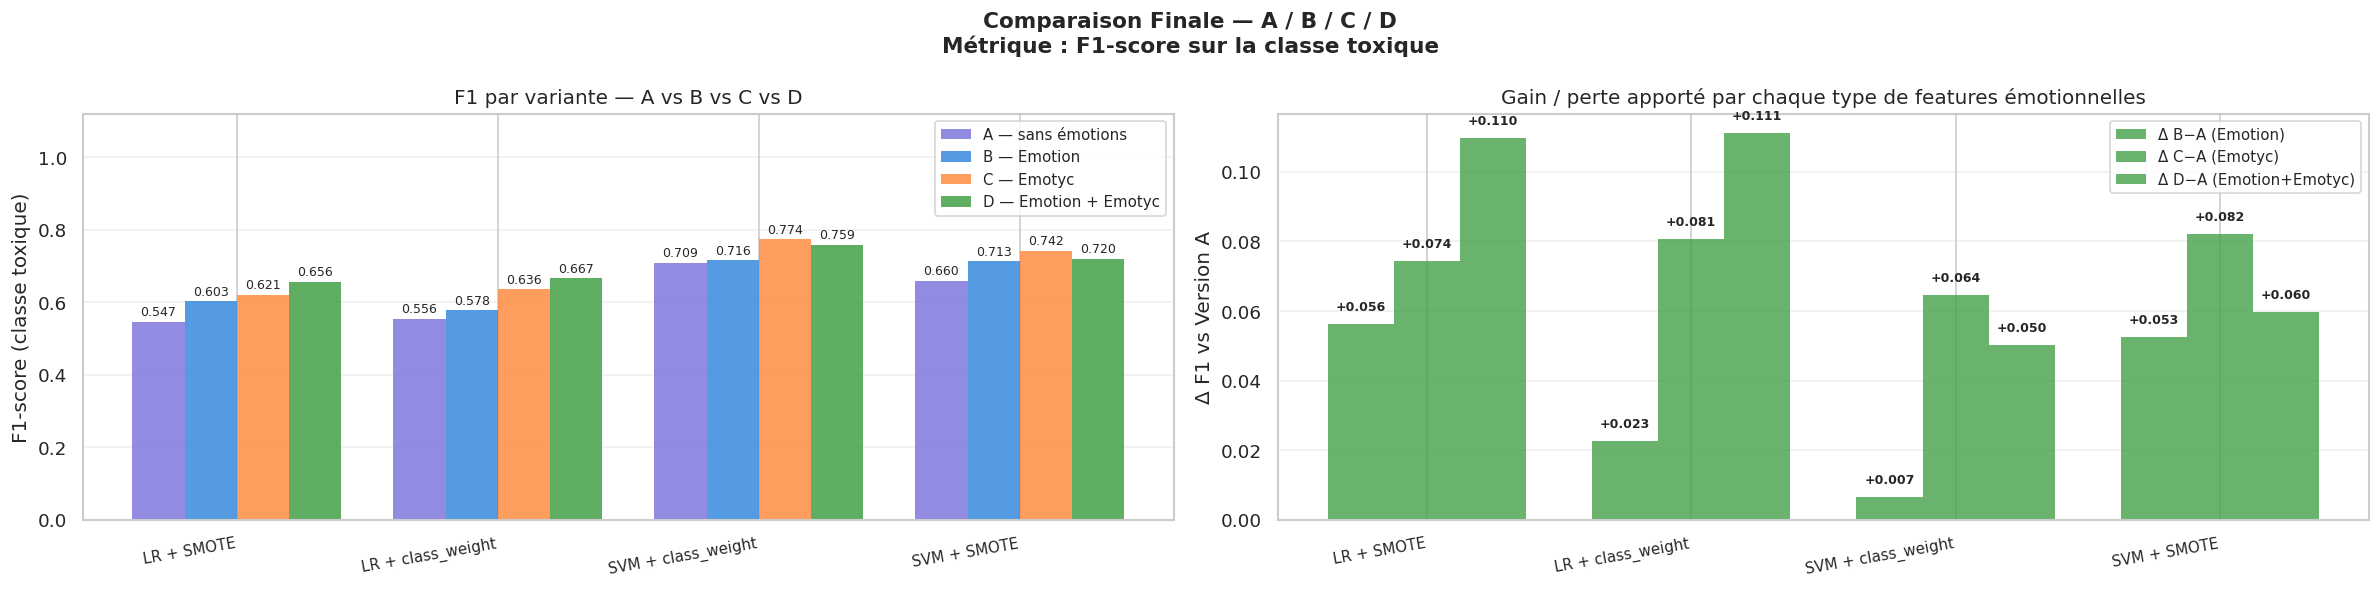

✅ Graphe comparaison finale A/B/C/D sauvegardé


In [ ]:


variantes = ['LR + SMOTE', 'LR + class_weight', 'SVM + class_weight', 'SVM + SMOTE']

f1_A = [metrics_A_v1['f1'], metrics_A_v2['f1'], metrics_A_v3['f1'], metrics_A_v4['f1']]
f1_B = [metrics_B_v1['f1'], metrics_B_v2['f1'], metrics_B_v3['f1'], metrics_B_v4['f1']]
f1_C = [metrics_C_v1['f1'], metrics_C_v2['f1'], metrics_C_v3['f1'], metrics_C_v4['f1']]
f1_D = [metrics_D_v1['f1'], metrics_D_v2['f1'], metrics_D_v3['f1'], metrics_D_v4['f1']]

# Tableau récapitulatif complet
df_abcd = pd.DataFrame({
    'Variante'           : variantes,
    'A — sans émotions'  : f1_A,
    'B — Emotion'        : f1_B,
    'C — Emotyc'         : f1_C,
    'D — Emotion+Emotyc' : f1_D,
    'Δ B−A'              : [b-a for a,b in zip(f1_A, f1_B)],
    'Δ C−A'              : [c-a for a,c in zip(f1_A, f1_C)],
    'Δ D−A'              : [d-a for a,d in zip(f1_A, f1_D)],
    'Δ D−B'              : [d-b for b,d in zip(f1_B, f1_D)],
    'Δ D−C'              : [d-c for c,d in zip(f1_C, f1_D)],
}).set_index('Variante')

print("\n=== Comparaison finale A / B / C / D ===")
display(df_abcd.round(4))

# ── Graphe 1 : F1 côte à côte ─────────────────────────────────────────────
x_pos = np.arange(len(variantes))
width = 0.2

fig, axes = plt.subplots(1, 2, figsize=(20, 5))
fig.suptitle('Comparaison Finale — A / B / C / D\n'
             'Métrique : F1-score sur la classe toxique',
             fontsize=13, fontweight='bold')

palette = [
    (f1_A, 'A — sans émotions',    '#7F77DD', -1.5),
    (f1_B, 'B — Emotion',          '#378ADD', -0.5),
    (f1_C, 'C — Emotyc',           '#FF8C42',  0.5),
    (f1_D, 'D — Emotion + Emotyc', '#43A047',  1.5),
]

for vals, label, color, offset in palette:
    bars = axes[0].bar(x_pos + offset*width, vals, width,
                       label=label, color=color, alpha=0.85, edgecolor='none')
    for bar, v in zip(bars, vals):
        axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.008,
                     f'{v:.3f}', ha='center', va='bottom', fontsize=7.5)

axes[0].set_xticks(x_pos)
axes[0].set_xticklabels(variantes, rotation=10, ha='right', fontsize=9)
axes[0].set_ylim(0, 1.12)
axes[0].set_ylabel('F1-score (classe toxique)')
axes[0].set_title('F1 par variante — A vs B vs C vs D')
axes[0].legend(fontsize=9)
axes[0].grid(axis='y', alpha=0.3)

# ── Graphe 2 : Deltas vs Version A ────────────────────────────────────────
delta_BA = [b-a for a,b in zip(f1_A, f1_B)]
delta_CA = [c-a for a,c in zip(f1_A, f1_C)]
delta_DA = [d-a for a,d in zip(f1_A, f1_D)]

x2    = np.arange(len(variantes))
width2 = 0.25

delta_palette = [
    (delta_BA, 'Δ B−A (Emotion)',          '#378ADD', -1),
    (delta_CA, 'Δ C−A (Emotyc)',           '#FF8C42',  0),
    (delta_DA, 'Δ D−A (Emotion+Emotyc)',   '#43A047',  1),
]

for deltas, label, color, offset in delta_palette:
    bar_colors = ['#43A047' if d > 0 else '#e53935' for d in deltas]
    bars = axes[1].bar(x2 + offset*width2, deltas, width2,
                       label=label, color=bar_colors, alpha=0.8, edgecolor='none')
    for bar, v in zip(bars, deltas):
        signe = '+' if v >= 0 else ''
        axes[1].text(bar.get_x()+bar.get_width()/2,
                     v + 0.003*(1 if v >= 0 else -1),
                     f'{signe}{v:.3f}', ha='center',
                     va='bottom' if v >= 0 else 'top',
                     fontsize=7.5, fontweight='bold')

axes[1].axhline(0, color='black', lw=0.8, ls='--')
axes[1].set_xticks(x2)
axes[1].set_xticklabels(variantes, rotation=10, ha='right', fontsize=9)
axes[1].set_ylabel('Δ F1 vs Version A')
axes[1].set_title('Gain / perte apporté par chaque type de features émotionnelles')
axes[1].legend(fontsize=9)
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('comparaison_finale_ABCD.png', dpi=180, bbox_inches='tight', facecolor='white')
plt.show()
print("✅ Graphe comparaison finale A/B/C/D sauvegardé")